# EDA Aplicada — Análise de Churn de Telecomunicações

## Visão Geral

Este notebook aplica técnicas de **Análise Exploratória de Dados (EDA)** em um dataset real de telecomunicações para entender o comportamento de **churn** (cancelamento de clientes).

### Etapas do Notebook
1. **Carregamento de dados** — leitura de três CSVs com dados separados por tema
2. **Transformação e limpeza** — conversão de tipos e padronização de nomes
3. **Unificação** — merge dos três DataFrames em um único
4. **Valores ausentes** — detecção, remoção e imputação de NaN
5. **Formulação de hipóteses** — definição das perguntas de negócio
6. **Análise Univariada** — distribuição individual de cada variável
7. **Análise Bivariada** — correlação entre variáveis com Qui-Quadrado
8. **Detecção de Outliers** — método IQR (Tukey) e Z-Score

---

In [2]:
import pandas as pd
import numpy as np

### Bibliotecas utilizadas

- **`pandas`** (`pd`) — biblioteca principal para manipulação de dados tabulares. Fornece as estruturas `DataFrame` (tabela 2D) e `Series` (coluna/vetor 1D), além de centenas de métodos para leitura, limpeza, transformação e análise de dados.
- **`numpy`** (`np`) — biblioteca de computação numérica. Usada aqui principalmente para `np.where()` (condicional vetorizado) e `np.abs()` (valor absoluto elementar).

## 1. Carregando os Dataframes

Os dados de churn estão divididos em **três arquivos CSV** separados, cada um com um tema diferente:

| Arquivo | Conteúdo | Variáveis-chave |
|---|---|---|
| `churn_customers.csv` | Dados demográficos dos clientes | ID, gênero, idade, parceiro, dependentes |
| `churn_contracts.csv` | Dados de contrato e cobrança | Tipo de contrato, cobranças mensais e totais |
| `churn_services.csv` | Serviços contratados | Internet, telefone, suporte técnico, etc. |

Para cada dataframe, utilizamos três métodos de inspeção:
- **`.head(n)`** — exibe as primeiras `n` linhas (padrão: 5); usado para visualizar a estrutura e os primeiros registros
- **`.tail(n)`** — exibe as últimas `n` linhas; útil para verificar se o final do arquivo está completo ou tem anomalias
- **`.info()`** — exibe metadados: nome das colunas, quantidade de valores não-nulos e o tipo de dado (`dtype`) de cada coluna

In [3]:
df_customers = pd.read_csv("./churn_customers.csv")
df_customers.head()

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [4]:
df_customers = pd.read_csv("./churn_customers.csv")
df_customers.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents
7038,6840-RESVB,Male,0,Yes,Yes
7039,2234-XADUH,Female,0,Yes,Yes
7040,4801-JZAZL,Female,0,Yes,Yes
7041,8361-LTMKD,Male,1,Yes,No
7042,3186-AJIEK,Male,0,No,No


In [5]:
df_customers = pd.read_csv("./churn_customers.csv")
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     7043 non-null   str  
 1   gender         7043 non-null   str  
 2   SeniorCitizen  7043 non-null   int64
 3   Partner        7043 non-null   str  
 4   Dependents     7043 non-null   str  
dtypes: int64(1), str(4)
memory usage: 275.2 KB


> **Leitura do `df_customers`**: possui 5 colunas. A coluna `SeniorCitizen` está codificada como inteiro (`0` = não idoso, `1` = idoso), e não como booleano — representação comum em datasets de ML para manter compatibilidade com algoritmos que esperam valores numéricos.

In [6]:
df_contracts = pd.read_csv("./churn_contracts.csv")
df_contracts.head()

,customerID,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,2,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df_contracts = pd.read_csv("./churn_contracts.csv")
df_contracts.tail()

,customerID,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,24,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,72,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,11,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,4,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,66,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [8]:
df_contracts = pd.read_csv("./churn_contracts.csv")
df_contracts.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   tenure            7043 non-null   int64  
 2   Contract          7043 non-null   str    
 3   PaperlessBilling  7043 non-null   str    
 4   PaymentMethod     7043 non-null   str    
 5   MonthlyCharges    7043 non-null   float64
 6   TotalCharges      7043 non-null   str    
 7   Churn             7043 non-null   str    
dtypes: float64(1), int64(1), str(6)
memory usage: 440.3 KB


In [9]:
df_services = pd.read_csv("./churn_services.csv")
df_services.head()

,customerID,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,No,No phone service,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,Yes,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,Yes,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,No,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Yes,No,Fiber optic,No,No,No,No,No,No


In [10]:
df_services = pd.read_csv("./churn_services.csv")
df_services.tail()

,customerID,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
7038,6840-RESVB,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes
7039,2234-XADUH,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes
7040,4801-JZAZL,No,No phone service,DSL,Yes,No,No,No,No,No
7041,8361-LTMKD,Yes,Yes,Fiber optic,No,No,No,No,No,No
7042,3186-AJIEK,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes


In [11]:
df_services = pd.read_csv("./churn_services.csv")
df_services.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customerID        7043 non-null   str  
 1   PhoneService      7043 non-null   str  
 2   MultipleLines     7043 non-null   str  
 3   InternetService   7043 non-null   str  
 4   OnlineSecurity    7043 non-null   str  
 5   OnlineBackup      7043 non-null   str  
 6   DeviceProtection  7043 non-null   str  
 7   TechSupport       7043 non-null   str  
 8   StreamingTV       7043 non-null   str  
 9   StreamingMovies   7043 non-null   str  
dtypes: str(10)
memory usage: 550.4 KB


> **Por que três arquivos separados?** Isso reflete boas práticas de banco de dados (normalização): cada tabela trata de um tema coeso. A coluna `customerID` presente nos três arquivos é a **chave primária** que será usada para realizar o `JOIN` entre eles. Antes do merge, é necessário transformar e limpar os dados individualmente.

## 2. Transformação de Tipos de Dados

A coluna `TotalCharges` (total cobrado do cliente) é lida como `object` (string) pelo pandas, pois contém **espaços em branco** onde deveriam estar valores numéricos. Precisamos convertê-la para `float`.

Veremos **três abordagens** para essa conversão — da mais simples (que falha) à mais robusta (que funciona):

- **Abordagem 1** — `astype(float)`: conversão direta; falha com qualquer string inválida
- **Abordagem 2** — `pd.to_numeric()`: mais robusto, mas também falha com espaços em branco
- **Abordagem 3** — `pd.to_numeric(errors='coerce')`: a correta; transforma valores inválidos em `NaN` em vez de lançar erro

In [12]:
# Transformar coluna TotalCharges para float - Abordagem 1: astype()
# df_contracts.TotalCharges = df_contracts.TotalCharges.astype(float)
# df_contracts.info()
# ValueError: could not convert string to float: ' ', ele não consegue converter os valores vazios para float 


> **Por que `astype(float)` falha?**
> O método `astype()` tenta converter cada valor diretamente. Ao encontrar qualquer string que não possa ser convertida para `float` (como o espaço `' '`), ele lança `ValueError` imediatamente — sem opção de contornar o erro individualmente.

In [13]:
# Transformar coluna TotalCharges para float - Abordagem 2: pd.to_numeric()
# df_contracts.TotalCharges = pd.to_numeric(df_contracts.TotalCharges)
# df_contracts.info()
# ValueError: Unable to parse string " " at position 488, ele não consegue converter os valores vazios para float


> **Por que `pd.to_numeric()` sem argumento também falha?**
> O comportamento padrão de `pd.to_numeric()` é idêntico ao `astype()`: lança `ValueError` ao encontrar strings inválidas. A diferença é que `pd.to_numeric()` aceita o parâmetro `errors=` que muda esse comportamento. Veja a solução na célula seguinte.

In [14]:
# Transformar coluna TotalCharges para float - Abordagem 2: pd.to_numeric() com argumento errors='coerce' para converter os valores vazios para NaN
df_contracts.TotalCharges = pd.to_numeric(df_contracts.TotalCharges, errors='coerce')
df_contracts.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   tenure            7043 non-null   int64  
 2   Contract          7043 non-null   str    
 3   PaperlessBilling  7043 non-null   str    
 4   PaymentMethod     7043 non-null   str    
 5   MonthlyCharges    7043 non-null   float64
 6   TotalCharges      7032 non-null   float64
 7   Churn             7043 non-null   str    
dtypes: float64(2), int64(1), str(5)
memory usage: 440.3 KB


In [15]:
# Após a transformação da coluna TotalCharges para float, podemos verificar a quantidade de valores ausentes (NaN) na coluna TotalCharges, que correspondem 
# aos valores vazios que não puderam ser convertidos para float.
df_contracts.TotalCharges.isna().sum()

np.int64(11)

## 3. Renomeação de Colunas

Renomear colunas melhora a legibilidade e a padronização dos dados. Exploraremos duas abordagens:

- **`df.rename(columns={...})`** — renomeia colunas específicas via dicionário `{nome_antigo: nome_novo}`
- **`df.columns = [...]`** — substitui **todos** os nomes de colunas de uma vez com uma lista

**Ponto crucial — Imutabilidade por padrão no pandas:**
A maioria dos métodos retorna uma **cópia** do DataFrame com as alterações, sem modificar o original. Para alterar no próprio objeto, use `inplace=True`. Caso contrário, atribua o resultado de volta à variável.

In [16]:
# Renomear coluna usando rename e dict
df_customers.rename(columns={'SeniorCitizen': 'Above65yo'})

,customerID,gender,Above65yo,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No
...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes
7039,2234-XADUH,Female,0,Yes,Yes
7040,4801-JZAZL,Female,0,Yes,Yes
7041,8361-LTMKD,Male,1,Yes,No


> **Armadilha do `inplace=False` (padrão)**:
> Sem `inplace=True`, o método `rename()` retorna um **novo DataFrame** com a coluna renomeada, mas o DataFrame original (`df_customers`) permanece inalterado. É um dos erros mais comuns para quem está aprendendo pandas. A célula abaixo usa `df_customers.info()` para confirmar que o rename anterior não surtiu efeito.

In [17]:
df_customers.info()
# Não é possível renomear a coluna usando rename e dict sem atribuir o resultado a uma variável ou usar o argumento inplace=True, pois o método rename retorna
#  uma cópia do DataFrame com as alterações, e não altera o DataFrame original.

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerID     7043 non-null   str  
 1   gender         7043 non-null   str  
 2   SeniorCitizen  7043 non-null   int64
 3   Partner        7043 non-null   str  
 4   Dependents     7043 non-null   str  
dtypes: int64(1), str(4)
memory usage: 275.2 KB


In [18]:
df_customers.rename(columns={'SeniorCitizen': 'Above65yo'}, inplace=True)
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   customerID  7043 non-null   str  
 1   gender      7043 non-null   str  
 2   Above65yo   7043 non-null   int64
 3   Partner     7043 non-null   str  
 4   Dependents  7043 non-null   str  
dtypes: int64(1), str(4)
memory usage: 275.2 KB


In [19]:
# Renomear todos os nomes das colunas usando columns
df_customers.columns = ['IDCliente', 'Genero', 'Mais65anos', 'TemParceiro', 'TemDependentes']
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   IDCliente       7043 non-null   str  
 1   Genero          7043 non-null   str  
 2   Mais65anos      7043 non-null   int64
 3   TemParceiro     7043 non-null   str  
 4   TemDependentes  7043 non-null   str  
dtypes: int64(1), str(4)
memory usage: 275.2 KB


> **Atenção ao usar `df.columns = [...]`**:
> A lista deve ter **exatamente** o mesmo número de elementos que a quantidade de colunas do DataFrame — sem mais, sem menos. A ordem importa: a primeira string renomeia a primeira coluna, a segunda renomeia a segunda, e assim por diante. Use este método apenas quando quiser renomear **todas** as colunas de uma vez.

## 4. Unificação dos Dataframes (Merge / Join)

Com os dados limpos e as colunas padronizadas, precisamos combinar os três dataframes em um único usando `pd.merge()`, equivalente ao `JOIN` do SQL.

**Parâmetros principais:**
- `on=` — usa a **mesma coluna** como chave nos dois DataFrames (nomes iguais)
- `left_on=` / `right_on=` — especifica colunas chave com **nomes diferentes** em cada lado
- O tipo padrão é **inner join** — apenas linhas com correspondência em ambos os DataFrames são mantidas

**Estratégia:** primeiro unimos `customers` + `services`, depois o resultado com `contracts`.

In [20]:
# Contar a quantidade de registros por Dataframe
len(df_customers), len(df_contracts), len(df_services)

(7043, 7043, 7043)

> **Verificar tamanhos antes do merge** é uma boa prática. Se após o merge o resultado tiver mais ou menos linhas do que o esperado, pode indicar:
> - **Chaves duplicadas** em um dos DataFrames (inner join geraria linhas extras)
> - **Dados ausentes na chave** (linhas sem correspondência seriam descartadas no inner join)
> - **Tipo de join incorreto** (considerar `how='left'` ou `how='outer'` se necessário)

In [21]:
# Renomear colunas
df_services.rename(columns={'customerID': 'IDCliente'}, inplace=True)

In [22]:
df_services.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   IDCliente         7043 non-null   str  
 1   PhoneService      7043 non-null   str  
 2   MultipleLines     7043 non-null   str  
 3   InternetService   7043 non-null   str  
 4   OnlineSecurity    7043 non-null   str  
 5   OnlineBackup      7043 non-null   str  
 6   DeviceProtection  7043 non-null   str  
 7   TechSupport       7043 non-null   str  
 8   StreamingTV       7043 non-null   str  
 9   StreamingMovies   7043 non-null   str  
dtypes: str(10)
memory usage: 550.4 KB


In [23]:
# Unificar Dataframe de Customers com Services
df_temp = pd.merge(df_customers, df_services, on='IDCliente')
df_temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   IDCliente         7043 non-null   str  
 1   Genero            7043 non-null   str  
 2   Mais65anos        7043 non-null   int64
 3   TemParceiro       7043 non-null   str  
 4   TemDependentes    7043 non-null   str  
 5   PhoneService      7043 non-null   str  
 6   MultipleLines     7043 non-null   str  
 7   InternetService   7043 non-null   str  
 8   OnlineSecurity    7043 non-null   str  
 9   OnlineBackup      7043 non-null   str  
 10  DeviceProtection  7043 non-null   str  
 11  TechSupport       7043 non-null   str  
 12  StreamingTV       7043 non-null   str  
 13  StreamingMovies   7043 non-null   str  
dtypes: int64(1), str(13)
memory usage: 770.5 KB


In [24]:
df_temp.head()

,IDCliente,Genero,Mais65anos,TemParceiro,TemDependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No


In [25]:
# Unificar Dataframe de Temp com Contracts usando nome de colunas distintos
df_churn_temp = pd.merge(df_temp, df_contracts, left_on=['IDCliente'], right_on=['customerID'])
df_churn_temp.info()
# CustomerID veio "duplicada", uma do DataFrame df_temp e outra do DataFrame df_contracts

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   IDCliente         7043 non-null   str    
 1   Genero            7043 non-null   str    
 2   Mais65anos        7043 non-null   int64  
 3   TemParceiro       7043 non-null   str    
 4   TemDependentes    7043 non-null   str    
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  customerID        7043 non-null   str    
 15  tenure            7043 non-null   int64  
 16  Contract          7043 non-null   str    
 17  Paperl

> **Coluna duplicada no merge**:
> Ao usar `left_on='IDCliente'` e `right_on='customerID'` (nomes diferentes), o pandas **mantém ambas as colunas** no resultado. Isso gera uma coluna redundante (`customerID`) que precisa ser removida. A solução correta é usar `drop()` na sequência, como feito a seguir — ou padronizar os nomes antes do merge.

In [26]:
# Agora como unificar os 3 dataframes mesmo com nomes de colunas distintos? Podemos usar o argumento left_on e right_on do método merge para especificar quais colunas 
# devem ser usadas para a junção, mesmo que tenham nomes diferentes.
df_churn = pd.merge(df_customers, df_services, on='IDCliente').merge(df_contracts, left_on='IDCliente', right_on='customerID')
df_churn.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   IDCliente         7043 non-null   str    
 1   Genero            7043 non-null   str    
 2   Mais65anos        7043 non-null   int64  
 3   TemParceiro       7043 non-null   str    
 4   TemDependentes    7043 non-null   str    
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  customerID        7043 non-null   str    
 15  tenure            7043 non-null   int64  
 16  Contract          7043 non-null   str    
 17  Paperl

In [27]:
# Removendo coluna de um dataframe
# axis igual a 0 indica que queremos remover uma linha, e axis igual a 1 indica que queremos remover uma coluna.
df_churn.drop(['customerID'], axis=1, inplace=True)

In [28]:
df_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   IDCliente         7043 non-null   str    
 1   Genero            7043 non-null   str    
 2   Mais65anos        7043 non-null   int64  
 3   TemParceiro       7043 non-null   str    
 4   TemDependentes    7043 non-null   str    
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  tenure            7043 non-null   int64  
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [29]:
df_churn.head()

,IDCliente,Genero,Mais65anos,TemParceiro,TemDependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,No,34,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,...,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,...,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 5. Lidando com Valores Ausentes

Valores ausentes (`NaN`) são comuns em dados reais. O pandas os representa como `NaN` em colunas numéricas.

**Ferramentas de detecção:**
- `df.isna()` — retorna DataFrame booleano: `True` onde há NaN
- `df.isna().sum()` — conta NaN **por coluna**
- `df.isna().any(axis=1).sum()` — conta **linhas** com pelo menos 1 NaN
- `df.isna().any(axis=0).sum()` — conta **colunas** com pelo menos 1 NaN

**Estratégias de tratamento:**
| Estratégia | Código | Quando usar |
|---|---|---|
| Remover coluna inteira | `dropna(axis=1)` | Coluna tem muitos NaN e é dispensável |
| Remover linhas com NaN | `dropna(axis=0)` | Poucos NaN e linhas não são críticas |
| Preencher com valor fixo | `fillna(0)` | NaN tem significado claro (ex: 0 = ausente) |
| Preencher com média | `fillna(df['col'].mean())` | Preservar a distribuição central |

> **Regra geral**: prefira **imputação** quando os NaN representam menos de ~5% do total.

In [30]:
# Detectar valores ausentes das colunas de um Dataframe
df_churn.isna().sum()

IDCliente            0
Genero               0
Mais65anos           0
TemParceiro          0
TemDependentes       0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
tenure               0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [31]:
# Detectar valores ausentes da coluna TotalCharges
df_churn['TotalCharges'].isna().sum()

np.int64(11)

In [32]:
# Quantas linhas tem pelo menos 1 coluna com valor ausente?
df_churn.isna().any(axis=1).sum()

np.int64(11)

In [33]:
# Quantas colunas tem pelo menos 1 linha com valor ausente?
df_churn.isna().any(axis=0).sum()

np.int64(1)

In [34]:
# Remover valores ausentes
# df_churn.drop(columns=['TotalCharges'], axis=1)
# Aqui dá o erro: ValueError: Cannot specify both 'axis' and 'index'/'columns' porque o método drop não aceita os argumentos columns e axis ao mesmo tempo, pois eles são 
# mutuamente exclusivos.

df_churn_remove_total_charges = df_churn.drop(columns=['TotalCharges'])
df_churn_remove_total_charges.head()

,IDCliente,Genero,Mais65anos,TemParceiro,TemDependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,34,One year,No,Mailed check,56.95,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,Yes


In [35]:
# Remover colunas com valores ausentes
df_churn.dropna(axis=1) # Aqui ele remove a coluna TotalCharges, pois é a única coluna com valores ausentes (NaN) no DataFrame df_churn

,IDCliente,Genero,Mais65anos,TemParceiro,TemDependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,34,One year,No,Mailed check,56.95,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,24,One year,Yes,Mailed check,84.80,No
7039,2234-XADUH,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,72,One year,Yes,Credit card (automatic),103.20,No
7040,4801-JZAZL,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,11,Month-to-month,Yes,Electronic check,29.60,No
7041,8361-LTMKD,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,4,Month-to-month,Yes,Mailed check,74.40,Yes


In [36]:
# Só remove colunas onde todas as linhas tem valor ausente
df_churn.dropna(axis=1, how='all')

,IDCliente,Genero,Mais65anos,TemParceiro,TemDependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,No,34,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,...,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,...,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,24,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,72,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,...,No,No,No,11,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,...,No,No,No,4,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


> **O parâmetro `axis=` no dropna:**
> - `axis=0` — opera sobre as **linhas** (remove linhas)
> - `axis=1` — opera sobre as **colunas** (remove colunas)
>
> **O parâmetro `how=`:**
> - `how='any'` (padrão) — remove se **pelo menos um** valor for NaN
> - `how='all'` — remove apenas se **todos** os valores forem NaN
>
> Combinar `axis` e `how` dá controle granular sobre o que remover.

In [37]:
# Só remove linhas onde todas as colunas tem valor ausente
df_churn.dropna(axis=0)

,IDCliente,Genero,Mais65anos,TemParceiro,TemDependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,No,34,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,...,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,...,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,24,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,72,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,...,No,No,No,11,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,...,No,No,No,4,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [38]:
# Remover linhas onde todas as colunas tem valor ausente
df_churn.dropna(axis=0, how='all')

,IDCliente,Genero,Mais65anos,TemParceiro,TemDependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,No,34,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,...,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,...,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,24,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,72,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,...,No,No,No,11,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,...,No,No,No,4,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [39]:
# Preencher todos os valores ausentes com 0 (NaN -> 0)
df_churn.fillna(0)

,IDCliente,Genero,Mais65anos,TemParceiro,TemDependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,No,34,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,...,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,...,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,24,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,72,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,...,No,No,No,11,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,...,No,No,No,4,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [40]:
# Preencher valores ausentes de colunas específicas com valores específicos
df_churn.fillna(value={'TotalCharges': 0, 'Genero': 'Não declarado'})

,IDCliente,Genero,Mais65anos,TemParceiro,TemDependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,No,34,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,...,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,...,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,24,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,72,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,...,No,No,No,11,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,...,No,No,No,4,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [41]:
media_total_charges = df_churn['TotalCharges'].mean()
media_total_charges

np.float64(2283.3004408418656)

In [42]:
# Se eu quisesse preencher a coluna TotalCharges com a média dos valores da coluna TotalCharges, eu poderia usar o método fillna com o argumento value para preencher 
# os valores ausentes com a média calculada.
df_churn.fillna(value={'TotalCharges': media_total_charges})

,IDCliente,Genero,Mais65anos,TemParceiro,TemDependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,No,1,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,No,34,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,...,No,No,No,2,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,...,Yes,No,No,45,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,No,2,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,...,Yes,Yes,Yes,24,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,72,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,...,No,No,No,11,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,...,No,No,No,4,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


> **Resumo das estratégias de imputação:**
> | Método | Vantagem | Desvantagem |
> |---|---|---|
> | `fillna(0)` | Simples e explícito | Pode distorcer análises se 0 não fizer sentido |
> | `fillna(média)` | Preserva a média da coluna | Reduz artificialmente a variância |
> | `fillna(mediana)` | Mais robusta a outliers | Pode ser inadequada para distribuições assimétricas |
> | `fillna(moda)` | Ideal para categóricas | Pode ser arbitrária se houver empate |
>
> **Importante**: `fillna()` **não modifica** o DataFrame original a menos que você use `inplace=True` ou reatribua: `df = df.fillna(...)`.

---

## Formulação de Hipóteses

Antes de iniciar a análise, formulamos perguntas de negócio claras em forma de hipóteses. Seguimos o framework de **H₀** (nula) e **H₁** (alternativa):

- **H₀** (nula): não existe associação entre as variáveis
- **H₁** (alternativa): existe associação entre as variáveis

### Hipóteses a investigar

#### H1 — Faixa etária e churn
> A variável `SeniorCitizen` tem forte associação com o churn?
> Hipótese: clientes idosos têm maior propensão a cancelar.

#### H2 — Tempo de contrato e churn
> Clientes com menos de 6 meses de `tenure` são mais propensos ao churn?
> Hipótese: clientes novos ainda não criaram vínculo e cancelam mais facilmente.

#### H3 — Tipo de contrato e churn
> Clientes com contratos mensais (`Contract`) são mais propensos ao churn?
> Hipótese: contratos mensais não exigem fidelidade, facilitando o cancelamento.

## 6. Análise Univariada

A análise univariada examina **uma variável por vez**, sem cruzá-la com outras. O objetivo é entender:
- A **distribuição** dos valores: quais existem e com que frequência
- As **medidas de tendência central**: média, mediana, moda
- As **medidas de dispersão**: desvio padrão, coeficiente de variação
- A **forma da distribuição**: simétrica, assimétrica, bimodal

**Para variáveis categóricas:**
- `value_counts()` — conta ocorrências de cada valor único
- `value_counts(normalize=True)` — retorna proporções (%) em vez de contagens
- `.plot.bar()` — gráfico de barras

**Para variáveis numéricas:**
- `.plot.hist()` — histograma da distribuição
- `.mean()` / `.median()` / `.mode()` / `.std()` — estatísticas descritivas

In [43]:
# Como identificar valores possíveis ou únicos de uma variavel
df_churn['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [44]:
# Como é a distribuição dos clientes em %
df_churn['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

[Text(0, 0, '5174'), Text(0, 0, '1869')]

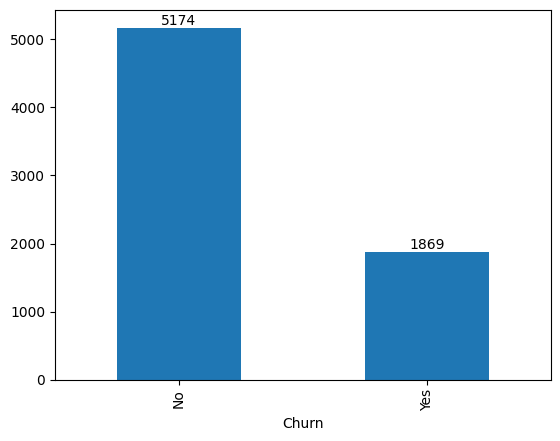

In [45]:
# Visualizar de forma gráfica a distribuição dos clientes usando a variável Churn como referência
ax = df_churn['Churn'].value_counts().plot.bar()
ax.bar_label(ax.containers[0])

[Text(0, 0, '0.73463'), Text(0, 0, '0.26537')]

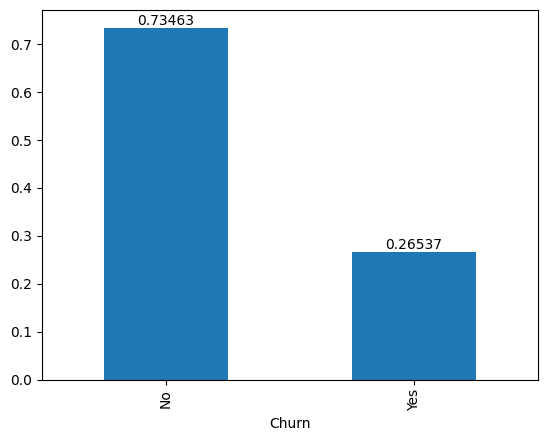

In [46]:
ax = df_churn['Churn'].value_counts(normalize=True).plot.bar()
ax.bar_label(ax.containers[0])

> **Anatomia do gráfico de barras com rótulos:**
> - `.plot.bar()` — cria o gráfico usando matplotlib integrado ao pandas
> - O retorno `ax` é o objeto `Axes` do matplotlib — a "tela" onde o gráfico é desenhado
> - `ax.containers[0]` — lista das barras geradas (cada barra é um `Rectangle` do matplotlib)
> - `ax.bar_label(ax.containers[0])` — adiciona o valor numérico de cada barra no seu topo
>
> Usar `normalize=True` antes do plot retorna proporções (entre 0 e 1), facilitando comparações independentes do volume total.

In [47]:
# Quais os tipos de contrato que podemos ter?
df_churn['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

[Text(0, 0, '3875'), Text(0, 0, '1695'), Text(0, 0, '1473')]

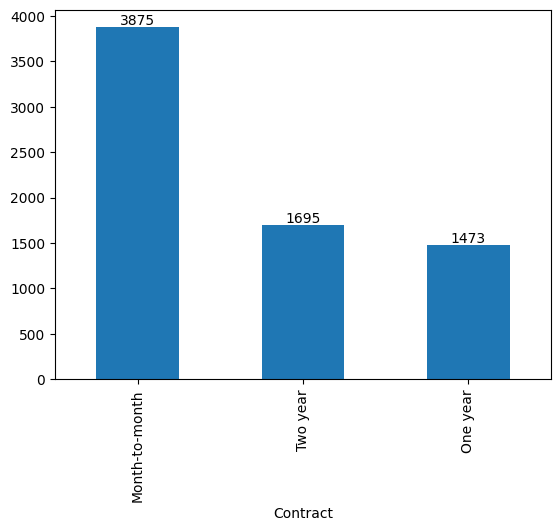

In [48]:
ax = df_churn['Contract'].value_counts().plot.bar()
ax.bar_label(ax.containers[0])

[Text(0, 0, '0.550192'), Text(0, 0, '0.240664'), Text(0, 0, '0.209144')]

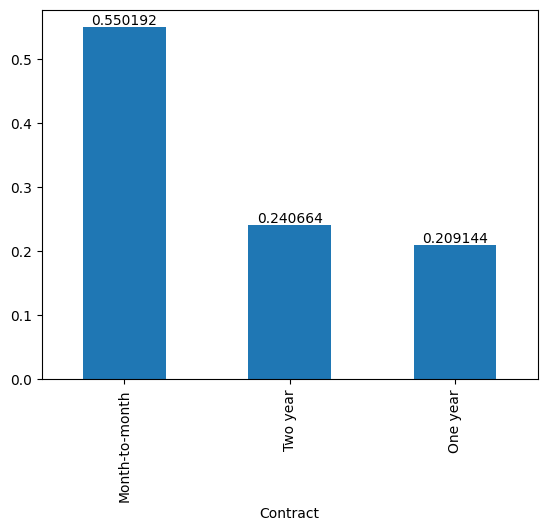

In [49]:
ax = df_churn['Contract'].value_counts(normalize=True).plot.bar()
ax.bar_label(ax.containers[0])

<Axes: ylabel='Frequency'>

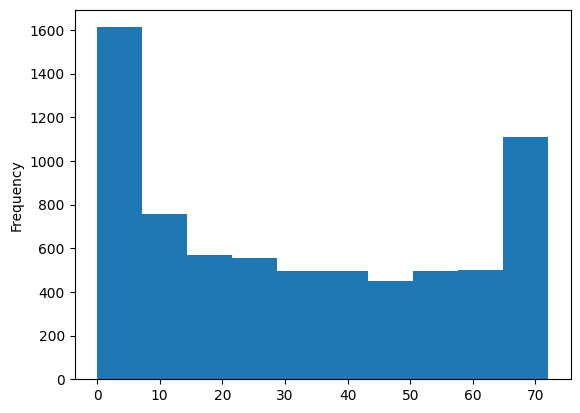

In [50]:
# Histograma do tempo de contrato dos clientes
df_churn['tenure'].plot.hist()

# A variavel tempo de contrato (tenure) não apresenta visualmente uma distribuilão do tipo normal, ela apresenta uma distribuição assimétrica, 
# com a maioria dos clientes tendo um tempo de contrato menor, e poucos clientes tendo um tempo de contrato maior.

<Axes: ylabel='Frequency'>

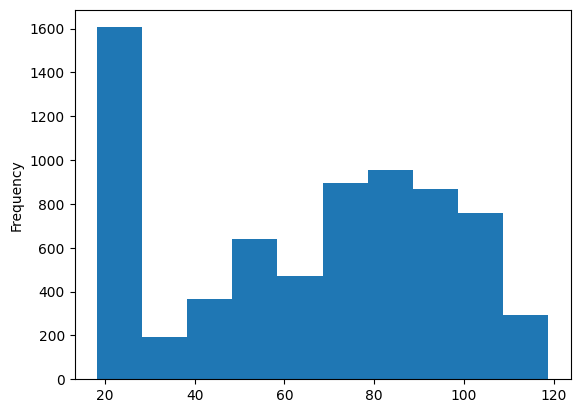

In [51]:
# Histograma do monthly charges
df_churn['MonthlyCharges'].plot.hist()

# O histograma do monthly charges apresenta uma distribuição mais próxima de uma distribuição normal, com a maioria dos clientes tendo um valor de 
# monthly charges em torno de 70, e poucos clientes tendo valores de monthly charges muito altos ou muito baixos.

> **Como ler um histograma:**
> O eixo X mostra o intervalo dos valores (*bins*) e o eixo Y mostra quantos registros caem em cada intervalo. Permite identificar:
> - **Distribuição normal (gaussiana)**: formato de "sino" — simétrica em torno da média
> - **Assimetria à direita (positiva)**: cauda longa no lado direito — maioria dos valores é pequena, com alguns muito grandes
> - **Assimetria à esquerda (negativa)**: cauda longa no lado esquerdo
> - **Bimodal**: dois picos — sugere duas subpopulações distintas nos dados
>
> O histograma de `tenure` é **assimétrico** (muitos clientes novos + muitos antigos), enquanto `MonthlyCharges` tem distribuição mais uniforme.

In [52]:
df_churn.tenure.mean()

np.float64(32.37114865824223)

In [53]:
df_churn.tenure.median()

np.float64(29.0)

In [54]:
df_churn.tenure.mode()

0    1
Name: tenure, dtype: int64

In [55]:
df_churn.tenure.std()

np.float64(24.55948102309446)

In [56]:
# Coeficiente de variação - o resultado do coeficiente mostrou que a variabilidade do tempo de contrato dos clientes é de aproximadamente 96,5% em relação 
# à média, o que indica uma alta dispersão dos dados em torno da média.

df_churn.tenure.std() / df_churn.tenure.mean() * 100

np.float64(75.86842617906674)

> **Resumo das estatísticas descritivas:**
> | Estatística | Código | O que mede |
> |---|---|---|
> | Média | `.mean()` | Centro aritmético dos dados; sensível a outliers |
> | Mediana | `.median()` | Valor central — divide os dados em 50%/50%; robusta a outliers |
> | Moda | `.mode()` | Valor mais frequente; pode ter múltiplos valores |
> | Desvio Padrão | `.std()` | Dispersão média em torno da média |
> | Coef. Variação | `std/mean × 100` | Dispersão relativa em %; permite comparar variáveis com escalas diferentes |
>
> Um CV acima de ~30% indica alta variabilidade. O `tenure` com CV ≈ 96,5% mostra que os tempos de contrato são muito dispersos — há clientes com 1 mês e clientes com 72 meses.

In [57]:
# Quantos clientes possuem 1 mês de contrato?
len(df_churn[df_churn.tenure == 1])

613

In [58]:
# Quanto os clientes com 1 mês de contrato representam em %% do total de clientes?
len(df_churn[df_churn.tenure == 1]) / len(df_churn) * 100

8.70367741019452

In [59]:
# Quantos clientes possuem entre 1 e 6 meses de contrato?
len(df_churn[(df_churn.tenure >= 1) & (df_churn.tenure <= 6)])

1470

In [60]:
# Apresentar a quantidade de clientes por tempo de contrato - Agrupamento com sumarização
df_churn.groupby('tenure').size().sort_values(ascending=False)

tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Length: 73, dtype: int64

<Axes: ylabel='tenure'>

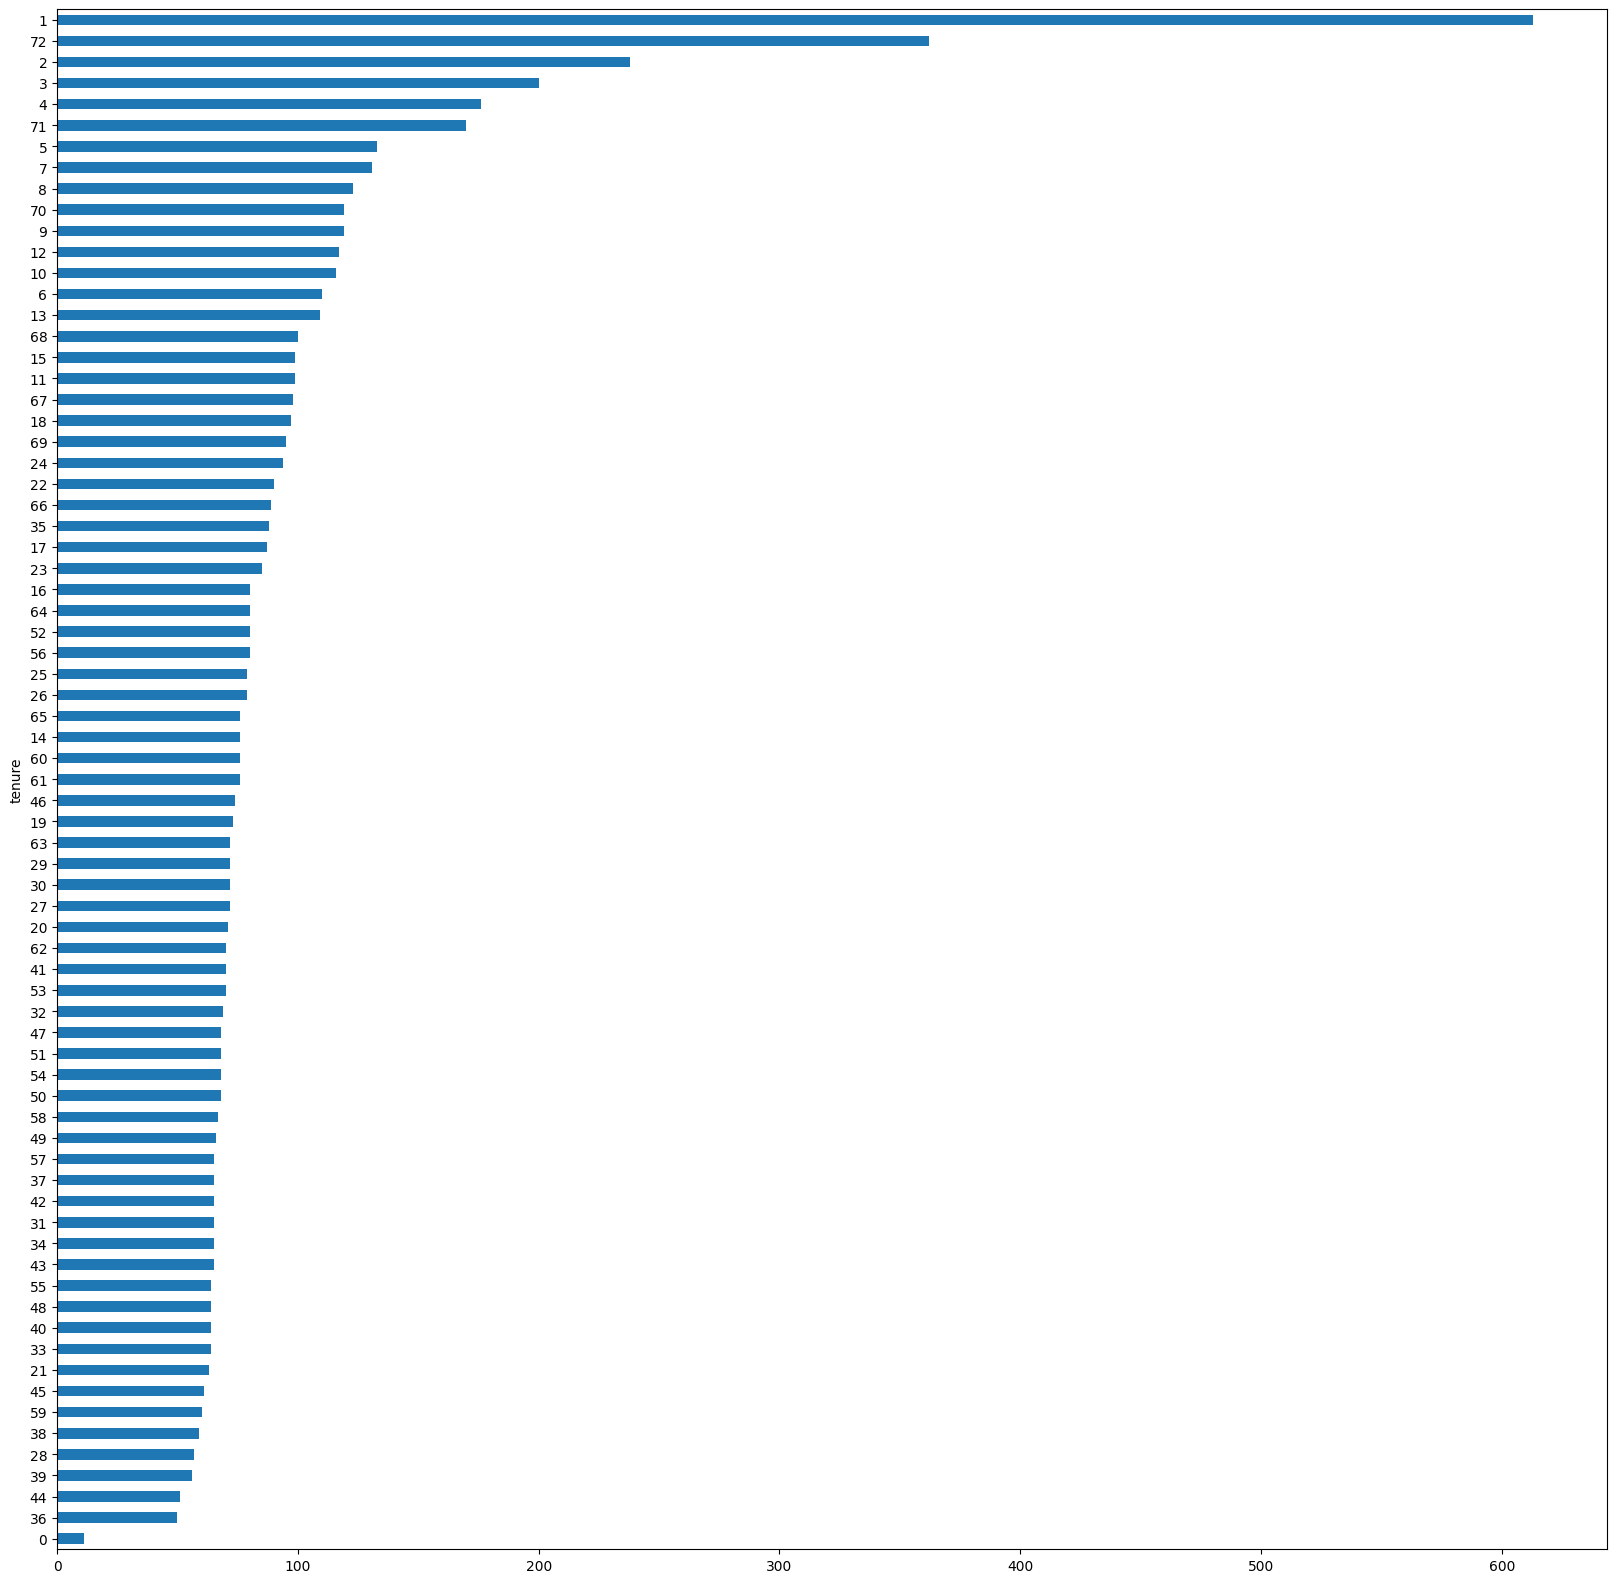

In [61]:
df_churn.groupby('tenure').size().sort_values().plot.barh(figsize=(20, 20))

> **`groupby().size()`** — equivalente ao `GROUP BY` + `COUNT(*)` do SQL:
> ```python
> SELECT tenure, COUNT(*) FROM df_churn GROUP BY tenure ORDER BY COUNT(*) ASC
> ```
> O `sort_values()` ordena os grupos pelo total de clientes. O `.plot.barh()` (horizontal) foi escolhido porque há muitos valores únicos de `tenure` (até 72 meses), tornando o gráfico vertical ilegível. Barras horizontais permitem ler os rótulos do eixo Y com facilidade.

## 7. Análise Bivariada

A análise bivariada investiga a **relação entre duas variáveis**. O método depende da combinação dos tipos:

| Variável 1 | Variável 2 | Ferramenta |
|---|---|---|
| Categórica | Categórica | Tabela de contingência + Qui-Quadrado (χ²) |
| Numérica | Numérica | Correlação de Pearson/Spearman + Scatter Plot |
| Categórica | Numérica | Converter numérica em categórica → Qui-Quadrado |

**Hipóteses testadas:**
- **H3**: `Contract` influencia o churn? → Qui-Quadrado
- **H2**: `tenure` < 6 meses influencia o churn? → binarização com `np.where` + Qui-Quadrado
- **Extra**: correlação entre `tenure` e `TotalCharges` → Pearson + Scatter

In [62]:
# Construir tabela de contingencia entre Tipo de Contrato e Churn
pd.crosstab(df_churn['Churn'], df_churn['Contract'], margins=True, margins_name='Total')

# Percebemos na tabela abaixo que a maioria dos clientes que possuem contrato mensal (Month-to-month) são os que mais cancelam o serviço (Churn = Yes), 
# enquanto os clientes com contrato de 1 ano (One year) e 2 anos (Two year) apresentam uma taxa de cancelamento muito menor. 
# Isso pode indicar que os clientes com contratos mais longos têm uma maior fidelidade à empresa, ou que a empresa oferece incentivos para manter os 
# clientes com contratos mais longos.

Contract,Month-to-month,One year,Two year,Total
Churn,,,,
No,2220,1307,1647,5174
Yes,1655,166,48,1869
Total,3875,1473,1695,7043


In [63]:
pd.crosstab(df_churn['Churn'], df_churn['Contract'], margins=True, margins_name='Total', normalize=True)

# O normalize=True na função crosstab calcula a proporção de cada combinação de valores em relação ao total, permitindo analisar a distribuição relativa 
# dos clientes que cancelaram o serviço (Churn = Yes) e os que não cancelaram (Churn = No) em relação aos diferentes tipos de contrato 
# (Month-to-month, One year, Two year).

# Essa análise pode ser melhor que a anterior porque ela permite comparar as proporções de clientes que cancelaram o serviço em relação ao total de 
# clientes, o que pode fornecer insights mais claros sobre a relação entre o tipo de contrato e a taxa de cancelamento, enquanto a tabela de contingência 
# anterior apenas mostra as contagens absolutas, sem considerar o tamanho relativo de cada grupo.

Contract,Month-to-month,One year,Two year,Total
Churn,,,,
No,0.315207,0.185574,0.233849,0.73463
Yes,0.234985,0.023570,0.006815,0.26537
Total,0.550192,0.209144,0.240664,1.00000


In [64]:
pd.crosstab(df_churn['Churn'], df_churn['Contract'], margins=True, margins_name='Total', normalize='index')

# Essa análise com normalize='index' pode ser melhor que a anterior usando normalize=true porque ela permite comparar as proporções de clientes que 
# cancelaram o serviço em relação ao total de clientes dentro de cada categoria de contrato, o que pode fornecer insights mais claros sobre a relação 
# entre o tipo de contrato e a taxa de cancelamento, enquanto a análise anterior usando normalize=true apenas mostra as proporções de clientes que 
# cancelaram o serviço em relação ao total de clientes, sem considerar a distribuição dentro de cada categoria de contrato.

Contract,Month-to-month,One year,Two year
Churn,,,
No,0.429068,0.252609,0.318322
Yes,0.885500,0.088818,0.025682
Total,0.550192,0.209144,0.240664


> **Os três modos do parâmetro `normalize` no `pd.crosstab()`:**
> | Valor | Proporção calculada sobre | Melhor para |
> |---|---|---|
> | `False` (padrão) | Contagens absolutas | Ver volumes reais |
> | `True` | **Total geral** de todas as células | Ver fatia de cada combinação no todo |
> | `'index'` | **Total de cada linha** | Comparar taxas entre grupos (ex: "de todos os churns, qual % era de cada contrato?") |
> | `'columns'` | **Total de cada coluna** | Ver distribuição dentro de cada categoria |
>
> O modo `normalize='index'` é geralmente o mais útil para analisar churn, pois responde: "qual é a taxa de churn dentro de cada tipo de contrato?" 

### Teste Qui-Quadrado de Pearson (χ²) — Associação entre Variáveis Categóricas

Para verificar se a associação observada na tabela de contingência é **estatisticamente significativa** (não é fruto do acaso), aplicamos o **Teste Qui-Quadrado**.

**Como funciona:**
1. **H₀**: as variáveis são independentes (sem associação)
2. **H₁**: existe associação entre as variáveis
3. O teste calcula o **estatístico χ²**: mede o quanto os valores observados se afastam dos esperados sob H₀
4. O **p-value** é a probabilidade de obter um resultado tão extremo assumindo que H₀ é verdadeira

**Regra de decisão:**
- `p-value < 0.05` → rejeitamos H₀ → associação estatisticamente significativa
- `p-value ≥ 0.05` → não rejeitamos H₀ → sem evidência suficiente

> H₀: não existe associação entre `Churn` e `Contract`
> H₁: existe associação entre `Churn` e `Contract`

In [65]:
# Gerar um DF da Crosstab sem os totais
df_crosstab_churn_contract = pd.crosstab(df_churn['Churn'], df_churn['Contract'])

In [66]:
# Calcular os Scores e P-Values
from scipy.stats import chi2_contingency

In [67]:
chi_scores_churn_contract = chi2_contingency(df_crosstab_churn_contract)
chi_scores_churn_contract

Chi2ContingencyResult(statistic=np.float64(1184.5965720837926), pvalue=np.float64(5.863038300673391e-258), dof=2, expected_freq=array([[2846.69175067, 1082.11018032, 1245.198069  ],
       [1028.30824933,  390.88981968,  449.801931  ]]))

> **Saída do `chi2_contingency()`** — a função retorna uma tupla com 4 elementos:
> - `[0]` — **χ² score** (estatístico): quanto maior, maior a diferença entre valores observados e esperados
> - `[1]` — **p-value**: probabilidade de H₀ ser verdadeira dado o resultado; usado para a decisão do teste
> - `[2]` — **graus de liberdade**: `(n_linhas - 1) × (n_colunas - 1)` da tabela de contingência
> - `[3]` — **frequências esperadas**: valores que ocorreriam se as variáveis fossem completamente independentes
>
> Nas próximas células, extraímos apenas `[0]` e `[1]` (score e p-value) para apresentar os resultados.

In [68]:
pd.set_option('display.float_format', lambda x: '%.10f' % x)

In [69]:
scores_churn_contract = pd.Series(chi_scores_churn_contract[0:2], index=['Qui2 Score', 'P-Value'])
scores_churn_contract

Qui2 Score   1184.5965720838
P-Value         0.0000000000
dtype: float64

In [70]:
df_chi_scores_churn_contract = pd.DataFrame(chi_scores_churn_contract[0:2], index=['Qui2 Score', 'P-Value'], columns=['Scores'])
df_chi_scores_churn_contract

,Scores
Qui2 Score,1184.5965720838
P-Value,0.0000000000


### Conclusão: Churn × Contract

O teste χ² retornou **p-value ≪ 0.05** (praticamente zero) → **rejeitamos H₀** com altíssima confiança.

**Conclusão**: existe associação estatisticamente significativa entre tipo de contrato e churn. O χ² alto indica associação forte — clientes com contrato mensal cancelam muito mais do que clientes com contratos anuais ou bianuais. **H3 confirmada.**

> **Atenção — associação ≠ causalidade**: o χ² indica que as variáveis estão associadas, mas não que uma *causa* a outra. Para estabelecer causalidade, seria necessário um desenho experimental controlado.

In [71]:
# Analisar a correlação entre uma variável qualitativa e uma variável quantitativa usando o teste de Chi-Square, transformando a variável quantitativa
# em uma variável qualitativa

# Hipótese: Clientes com menos de 6 meses de contrato é mais propenso ao Churn

# Criar uma coluna nova no Dataframe com base em uma condição de outra coluna

df_churn['TempoMenor6Meses'] = np.where(df_churn['tenure'] < 6, 'Yes', 'No')
df_churn.head()

,IDCliente,Genero,Mais65anos,TemParceiro,TemDependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TempoMenor6Meses
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,1,Month-to-month,Yes,Electronic check,29.8500000000,29.8500000000,No,Yes
1,5575-GNVDE,Male,0,No,No,Yes,No,DSL,Yes,No,...,No,No,34,One year,No,Mailed check,56.9500000000,1889.5000000000,No,No
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,...,No,No,2,Month-to-month,Yes,Mailed check,53.8500000000,108.1500000000,Yes,Yes
3,7795-CFOCW,Male,0,No,No,No,No phone service,DSL,Yes,No,...,No,No,45,One year,No,Bank transfer (automatic),42.3000000000,1840.7500000000,No,No
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,2,Month-to-month,Yes,Electronic check,70.7000000000,151.6500000000,Yes,Yes


> **`np.where(condição, valor_se_true, valor_se_false)`** — equivalente a um `IF/ELSE` vetorizado aplicado elemento a elemento em todo o array/Series de uma vez, sem loop explícito.
>
> Aqui, convertemos a variável numérica `tenure` em uma variável categórica binária (`'Yes'`/`'No'`), permitindo aplicar o Qui-Quadrado — que exige variáveis categóricas. Essa técnica de **binarização** é muito usada para testar hipóteses com limiares de negócio ("cliente novo" = menos de 6 meses).

In [72]:
df_crosstab_churn_tenure = pd.crosstab(df_churn['Churn'], df_churn['TempoMenor6Meses'])
df_crosstab_churn_tenure

TempoMenor6Meses,No,Yes
Churn,,
No,4547,627
Yes,1125,744


In [73]:
chi_scores_churn_tenure = chi2_contingency(df_crosstab_churn_tenure)
chi_scores_churn_tenure

Chi2ContingencyResult(statistic=np.float64(669.7216158287102), pvalue=np.float64(1.1485390172689518e-147), dof=1, expected_freq=array([[4166.82209286, 1007.17790714],
       [1505.17790714,  363.82209286]]))

In [74]:
scores_churn_tenure = pd.Series(chi_scores_churn_tenure[0])
pvalues_churn_tenure = pd.Series(chi_scores_churn_tenure[1])

In [75]:
df_chi_scores_churn_tenure = pd.DataFrame({
  'Qui2': scores_churn_tenure, 
  'p-value': pvalues_churn_tenure
  })

In [76]:
# Como o p-value é <= 0.05, podemos rejeitar a hipótese nula e concluir que existe uma associação estatisticamente significativa entre ter um tempo de 
# contrato menor que 6 meses e a propensão ao Churn, ou seja, clientes com menos de 6 meses de contrato são mais propensos a cancelar o serviço 
# (Churn = Yes) do que clientes com 6 meses ou mais de contrato.
df_chi_scores_churn_tenure

,Qui2,p-value
0,669.7216158287,0.0000000000


### Conclusão: Churn × TempoMenor6Meses

O **p-value ≤ 0.05** confirma que existe associação significativa → **H2 confirmada**.

Clientes com menos de 6 meses de contrato têm **maior propensão ao churn**. Isso é consistente com a intuição de negócio: clientes novos ainda não desenvolveram lealdade à empresa e são mais suscetíveis a cancelar, especialmente diante de uma experiência ruim no início do relacionamento.

In [77]:
# Correlação entre 2 variaveis numéricas (apenas para aprendizado)
# A intuição é que quanto mais tempo de contrato maior o valor pago.

df_churn.tenure.corr(df_churn.TotalCharges) # Pearson 0.82
#df_churn.tenure.corr(df_churn.TotalCharges, method='spearman') # Spearman 0.88

# Há uma forte correção entre o tempo de contrato (tenure) e o valor total pago (TotalCharges), indicando que clientes com um tempo de contrato mais longo 
# tendem a pagar mais, o que é consistente com a intuição de que quanto mais tempo de contrato maior o valor pago.

np.float64(0.8258804609332018)

<Axes: xlabel='tenure', ylabel='TotalCharges'>

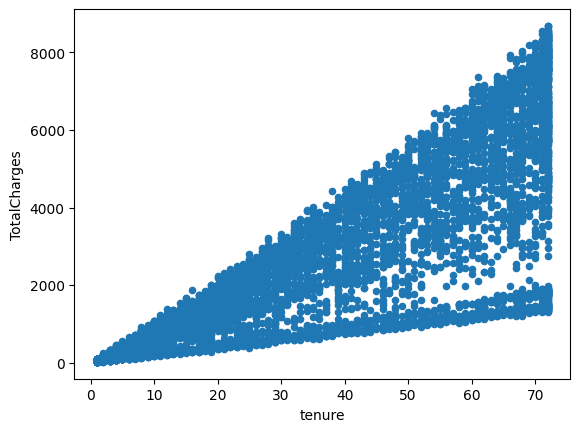

In [78]:
# Apresentar plot Scatter entre Tenure e TotalCharges
df_churn.plot.scatter(x='tenure', y='TotalCharges')

> **Correlação de Pearson vs Spearman:**
> | Método | Mede | Pressuposto | Sensível a outliers? |
> |---|---|---|---|
> | **Pearson** (padrão) | Correlação linear | Relação é uma linha reta | Sim |
> | **Spearman** | Correlação por ranking (monotônica) | Sem pressuposto de linearidade | Menos |
>
> O valor de **0.82 (Pearson)** e **0.88 (Spearman)** indica **forte correlação positiva**: clientes com mais tempo de contrato tendem a pagar mais no total. O Scatter Plot confirma essa tendência visualmente — os pontos formam uma "nuvem" com inclinação ascendente clara.

## 8. Detecção de Outliers

**Outliers** são valores que se desviam significativamente do padrão dos dados. Podem ser:
- **Erros de medição/digitação** → corrigir ou remover
- **Valores legítimos mas raros** → investigar antes de agir
- **Informação valiosa** → em fraude e falhas, outliers são o foco principal

**Dois métodos complementares:**

| Método | Indicado para | Como funciona |
|---|---|---|
| **IQR (Tukey)** | Distribuições **não-normais** | Limites baseados em quartis; robusto a outliers |
| **Z-Score** | Distribuições **normais** | Distância da média em unidades de desvio padrão |

**Passos desta seção:**
1. Verificar estado do DataFrame (remover NaN residuais)
2. Visualizar com Box Plot
3. Filtrar para contratos mensais (subconjunto mais relevante)
4. Confirmar distribuição com histograma
5. Aplicar método IQR
6. Aplicar método Z-Score e comparar

In [79]:
df_churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   IDCliente         7043 non-null   str    
 1   Genero            7043 non-null   str    
 2   Mais65anos        7043 non-null   int64  
 3   TemParceiro       7043 non-null   str    
 4   TemDependentes    7043 non-null   str    
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  tenure            7043 non-null   int64  
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [80]:
# Remover linhas com valores nulos
df_churn.dropna(axis=0,inplace=True)

In [81]:
df_churn.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   IDCliente         7032 non-null   str    
 1   Genero            7032 non-null   str    
 2   Mais65anos        7032 non-null   int64  
 3   TemParceiro       7032 non-null   str    
 4   TemDependentes    7032 non-null   str    
 5   PhoneService      7032 non-null   str    
 6   MultipleLines     7032 non-null   str    
 7   InternetService   7032 non-null   str    
 8   OnlineSecurity    7032 non-null   str    
 9   OnlineBackup      7032 non-null   str    
 10  DeviceProtection  7032 non-null   str    
 11  TechSupport       7032 non-null   str    
 12  StreamingTV       7032 non-null   str    
 13  StreamingMovies   7032 non-null   str    
 14  tenure            7032 non-null   int64  
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

<Axes: >

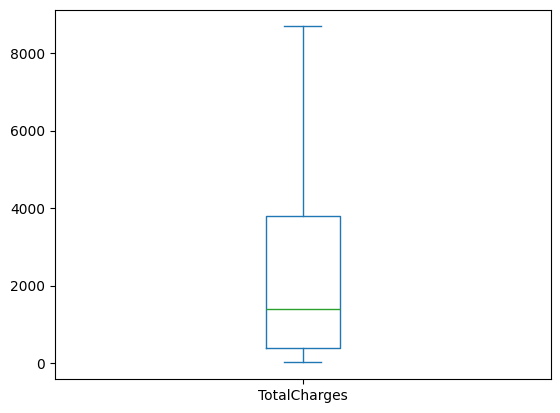

In [82]:
df_churn['TotalCharges'].plot.box()

TotalCharges    Axes(0.125,0.11;0.775x0.77)
dtype: object

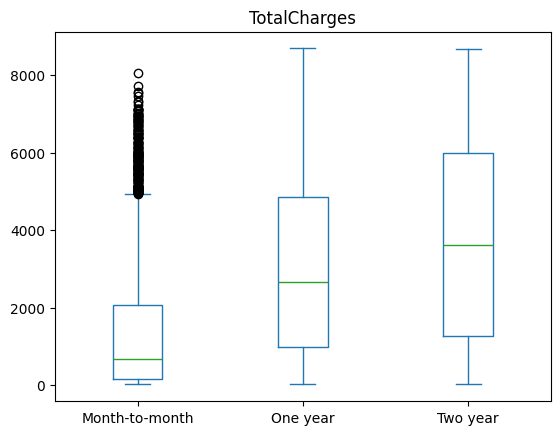

In [83]:
df_churn.plot.box(column='TotalCharges', by='Contract')

> **Como ler um Box Plot:**
> - **Linha central** = mediana (Q2 — percentil 50%)
> - **Caixa** = intervalo interquartil (IQR = Q3 − Q1) — contém os 50% centrais dos dados
> - **Bigodes (whiskers)** = extensão até 1.5 × IQR a partir da caixa
> - **Pontos fora dos bigodes** = outliers candidatos
>
> O Box Plot agrupado por `Contract` (`by='Contract'`) gera um gráfico separado para cada tipo de contrato. Clientes com contratos mais longos naturalmente acumulam mais em `TotalCharges`, então espera-se mediana e outliers mais altos.

In [84]:
df_churn_month = df_churn[df_churn.Contract == 'Month-to-month']
df_churn_month

,IDCliente,Genero,Mais65anos,TemParceiro,TemDependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TempoMenor6Meses
0,7590-VHVEG,Female,0,Yes,No,No,No phone service,DSL,No,Yes,...,No,No,1,Month-to-month,Yes,Electronic check,29.8500000000,29.8500000000,No,Yes
2,3668-QPYBK,Male,0,No,No,Yes,No,DSL,Yes,Yes,...,No,No,2,Month-to-month,Yes,Mailed check,53.8500000000,108.1500000000,Yes,Yes
4,9237-HQITU,Female,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,2,Month-to-month,Yes,Electronic check,70.7000000000,151.6500000000,Yes,Yes
5,9305-CDSKC,Female,0,No,No,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,8,Month-to-month,Yes,Electronic check,99.6500000000,820.5000000000,Yes,No
6,1452-KIOVK,Male,0,No,Yes,Yes,Yes,Fiber optic,No,Yes,...,Yes,No,22,Month-to-month,Yes,Credit card (automatic),89.1000000000,1949.4000000000,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7033,9767-FFLEM,Male,0,No,No,Yes,No,Fiber optic,No,No,...,No,No,38,Month-to-month,Yes,Credit card (automatic),69.5000000000,2625.2500000000,No,No
7034,0639-TSIQW,Female,0,No,No,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,No,67,Month-to-month,Yes,Credit card (automatic),102.9500000000,6886.2500000000,Yes,No
7035,8456-QDAVC,Male,0,No,No,Yes,No,Fiber optic,No,No,...,Yes,No,19,Month-to-month,Yes,Bank transfer (automatic),78.7000000000,1495.1000000000,No,No
7040,4801-JZAZL,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,...,No,No,11,Month-to-month,Yes,Electronic check,29.6000000000,346.4500000000,No,No


<Axes: ylabel='Frequency'>

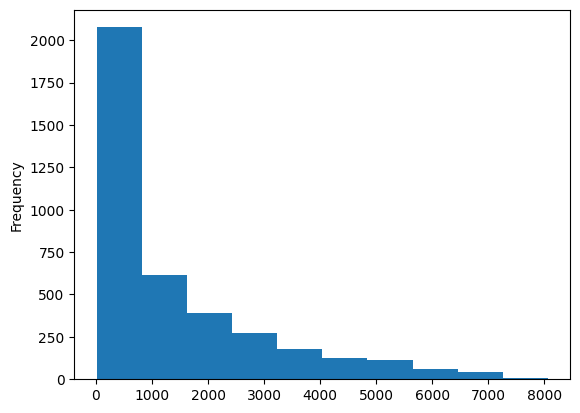

In [85]:
# Histograma - Checar visualmente se os dados seguem uma distribuição normal
df_churn_month['TotalCharges'].plot.hist()

# O resultado mostra que a distribuição dos valores de TotalCharges para os clientes com contrato mensal (Month-to-month) é assimétrica, 
# com a maioria dos clientes tendo valores de TotalCharges mais baixos, e poucos clientes tendo valores de TotalCharges mais altos, o que indica que 
# os dados não seguem uma distribuição normal.

In [86]:
# 1º método para analisar outliers que não estão em uma distribuição normal - IQR (Método de Tukey)
# IQR = 3º quartil - 1º quartil
q1_total_charges_month = df_churn_month['TotalCharges'].quantile(0.25)
q3_total_charges_month = df_churn_month['TotalCharges'].quantile(0.75)

iqr_total_charges_month = q3_total_charges_month - q1_total_charges_month
iqr_total_charges_month

np.float64(1906.4)

> **Método IQR (Método de Tukey) — passo a passo:**
> ```
> Q1  = percentil 25% (primeiro quartil)
> Q3  = percentil 75% (terceiro quartil)
> IQR = Q3 - Q1
>
> Limite Inferior = Q1 - 1.5 × IQR
> Limite Superior = Q3 + 1.5 × IQR
> ```
> Qualquer valor **abaixo do limite inferior** ou **acima do limite superior** é considerado outlier.
> O fator `1.5` é a convenção de Tukey — valores além do fator `3.0` são chamados de "outliers extremos".

In [87]:
# Definir os limites inferior e superior para identificar outliers usando o método IQR
limite_inferior_total_charges_month = q1_total_charges_month - (1.5 * iqr_total_charges_month)
limite_superior_total_charges_month = q3_total_charges_month + (1.5 * iqr_total_charges_month)

limite_inferior_total_charges_month, limite_superior_total_charges_month

(np.float64(-2699.5000000000005), np.float64(4926.1))

In [88]:
df_churn_month[
  (df_churn_month['TotalCharges'] < limite_inferior_total_charges_month) | 
  (df_churn_month['TotalCharges'] > limite_superior_total_charges_month)
]

# Então eu tenho 200 outliers segundo o método de Tukey, ou seja, 200 clientes com contrato mensal (Month-to-month) que possuem valores de 
# TotalCharges considerados atípicos

,IDCliente,Genero,Mais65anos,TemParceiro,TemDependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TempoMenor6Meses
13,0280-XJGEX,Male,0,No,No,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,49,Month-to-month,Yes,Bank transfer (automatic),103.7000000000,5036.3000000000,Yes,No
61,1215-FIGMP,Male,0,No,No,Yes,Yes,Fiber optic,No,Yes,...,Yes,No,60,Month-to-month,Yes,Bank transfer (automatic),89.9000000000,5450.7000000000,No,No
93,6067-NGCEU,Female,0,No,No,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,65,Month-to-month,Yes,Credit card (automatic),111.0500000000,7107.0000000000,No,No
110,0486-HECZI,Male,0,Yes,No,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,No,55,Month-to-month,Yes,Electronic check,96.7500000000,5238.9000000000,Yes,No
197,6168-YBYNP,Male,0,No,No,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,59,Month-to-month,Yes,Electronic check,111.3500000000,6519.7500000000,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6897,2363-BJLSL,Male,0,No,No,Yes,No,DSL,No,Yes,...,Yes,Yes,62,Month-to-month,Yes,Bank transfer (automatic),80.4000000000,4981.1500000000,No,No
6952,6394-MFYNG,Female,0,No,No,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,48,Month-to-month,Yes,Bank transfer (automatic),107.4000000000,5121.3000000000,Yes,No
6965,7789-CRUVC,Female,1,Yes,No,Yes,Yes,Fiber optic,Yes,Yes,...,No,No,61,Month-to-month,Yes,Credit card (automatic),94.2000000000,5895.4500000000,No,No
7023,1035-IPQPU,Female,1,Yes,No,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,63,Month-to-month,Yes,Electronic check,103.5000000000,6479.4000000000,No,No


In [89]:
# 2º método para analisar outliers que estão em uma distribuição normal - Z-Score
# O Z-Score é uma medida de quantos desvios padrão um valor está afastado da média. Valores de Z-Score acima de 3 ou abaixo de -3 são geralmente 
# considerados outliers em uma distribuição normal.

from scipy.stats import zscore

In [90]:
z = np.abs(zscore(df_churn_month['TotalCharges']))
z

array([0.83003585, 0.78151294, 0.75455577, ..., 0.07798705, 0.63383722,
       0.65853247], shape=(3875,))

In [91]:
df_churn_month[z > 3]

,IDCliente,Genero,Mais65anos,TemParceiro,TemDependentes,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TempoMenor6Meses
93,6067-NGCEU,Female,0,No,No,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,65,Month-to-month,Yes,Credit card (automatic),111.0500000000,7107.0000000000,No,No
197,6168-YBYNP,Male,0,No,No,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,59,Month-to-month,Yes,Electronic check,111.3500000000,6519.7500000000,No,No
339,1343-EHPYB,Male,0,Yes,No,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,63,Month-to-month,Yes,Electronic check,103.4000000000,6603.0000000000,Yes,No
402,0979-PHULV,Male,0,Yes,Yes,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,69,Month-to-month,Yes,Credit card (automatic),99.4500000000,7007.6000000000,Yes,No
445,7752-XUSCI,Female,0,No,No,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,60,Month-to-month,Yes,Electronic check,105.9000000000,6396.4500000000,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6565,1548-FEHVL,Male,0,Yes,No,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,61,Month-to-month,Yes,Electronic check,106.2000000000,6375.2000000000,No,No
6587,7426-GSWPO,Male,1,No,No,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Yes,64,Month-to-month,Yes,Bank transfer (automatic),103.5000000000,6548.6500000000,No,No
6713,4989-LIXVT,Male,1,No,No,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,68,Month-to-month,Yes,Electronic check,95.9000000000,6503.2000000000,No,No
7023,1035-IPQPU,Female,1,Yes,No,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,63,Month-to-month,Yes,Electronic check,103.5000000000,6479.4000000000,No,No


---

## Conclusão Final — Detecção de Outliers

**Método IQR (Tukey)**: identificou **~200 outliers** em `TotalCharges` para clientes com contrato mensal — valores muito acima do padrão esperado.

**Método Z-Score**: identificou clientes com `TotalCharges` mais de **3 desvios padrão** acima da média. Por depender da média e do desvio padrão (ambos sensíveis a outliers), tende a ser mais conservador que o IQR.

> **Como lidar com os outliers encontrados?** Depende do contexto:
> - **Erro de dados** → corrigir ou remover
> - **Valor legítimo raro** → manter, mas monitorar impacto nos modelos
> - **Para modelos de ML** → testar com e sem outliers e comparar a performance

---

## Resumo das Hipóteses

| Hipótese | Resultado | Método Utilizado |
|---|---|---|
| H1: Faixa etária (`SeniorCitizen`) → churn? | Não testada neste notebook | — |
| H2: `tenure` < 6 meses → maior churn? | ✅ Confirmada (p-value < 0.05) | Qui-Quadrado (χ²) |
| H3: Contratos mensais → maior churn? | ✅ Confirmada (p-value < 0.05) | Qui-Quadrado (χ²) |
| Correlação `tenure` × `TotalCharges` | ✅ Forte correlação positiva (Pearson = 0.82) | Correlação de Pearson |

## 9. Automatizando EDA

In [92]:
import sweetviz as sv

sv_churn_report = sv.analyze(df_churn, target_feat='Churn')
# O argumento target_feat='Churn' é utilizado para indicar que a variável 'Churn' é a variável alvo (target) da análise, ou seja, a variável que queremos 
# entender melhor em relação às outras variáveis do DataFrame df_churn. Isso permite que o Sweetviz gere insights e visualizações específicas para a 
# variável 'Churn', facilitando a compreensão dos fatores que podem estar relacionados ao cancelamento do serviço pelos clientes.

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)



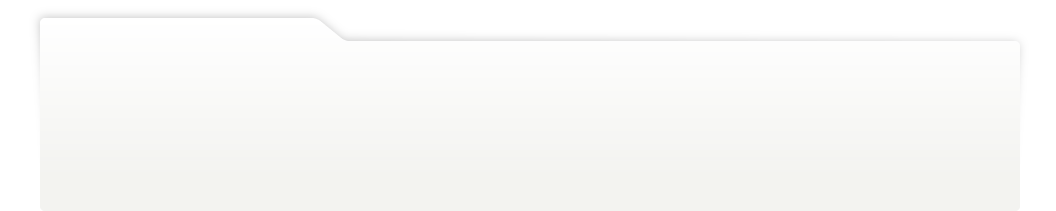
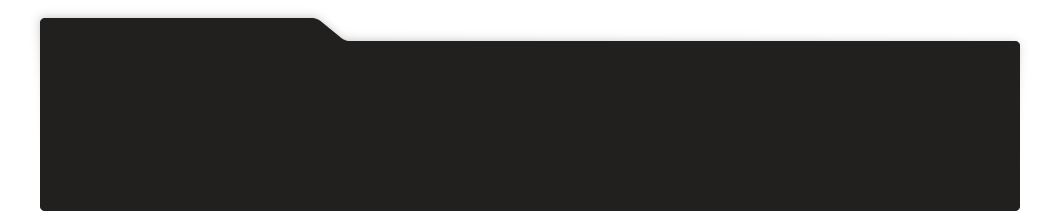
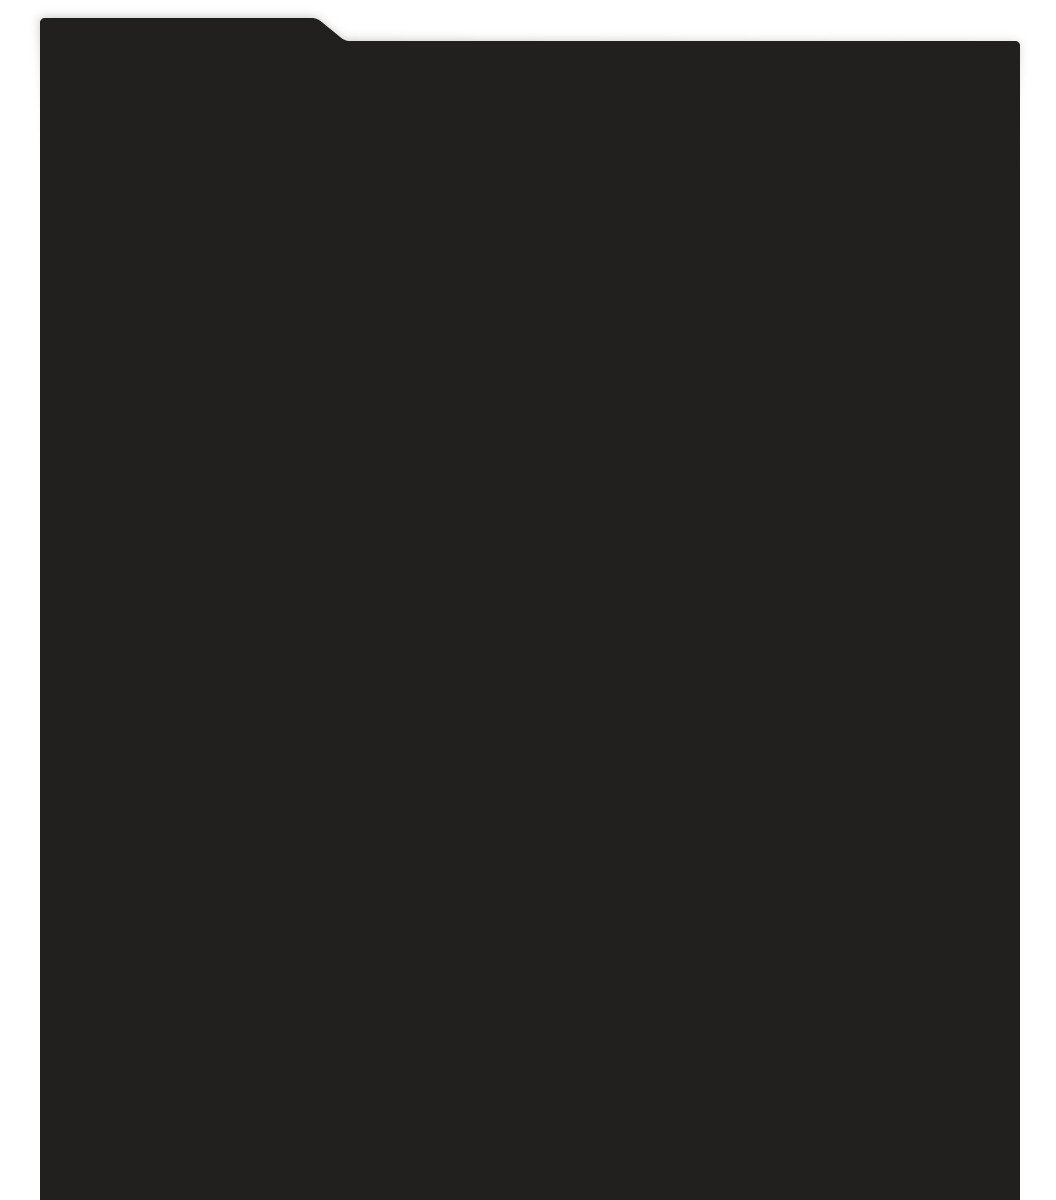
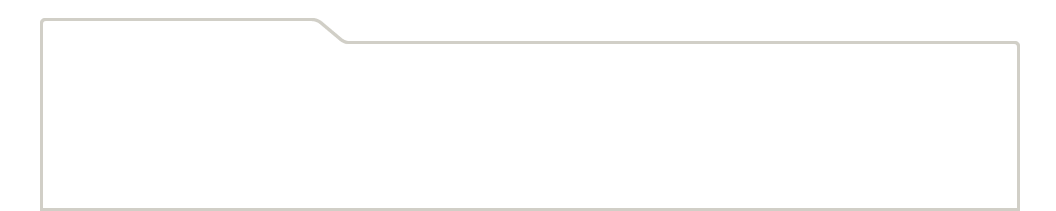
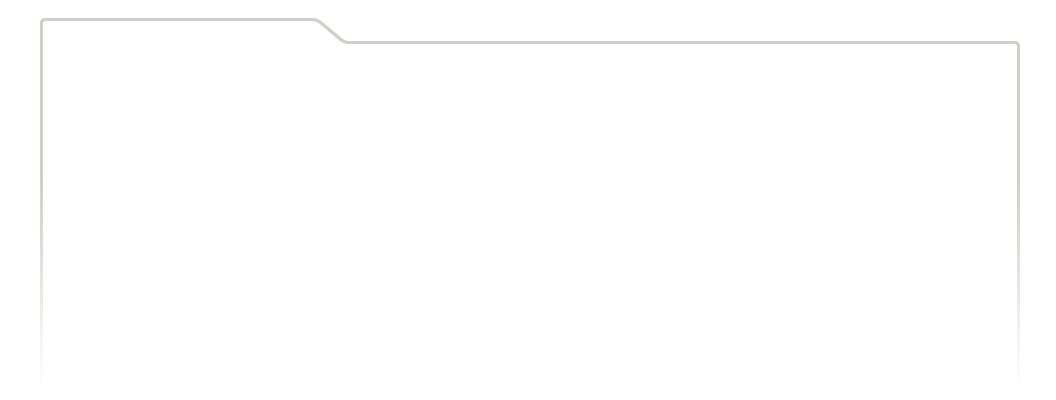
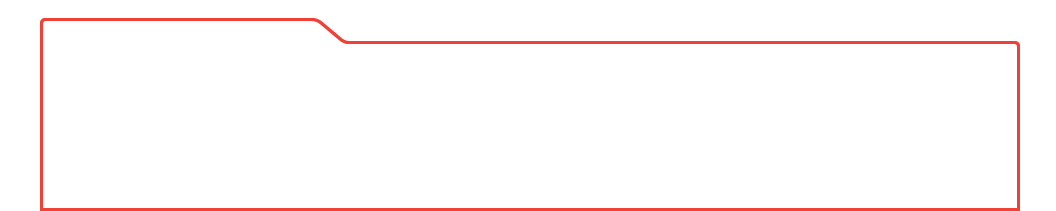
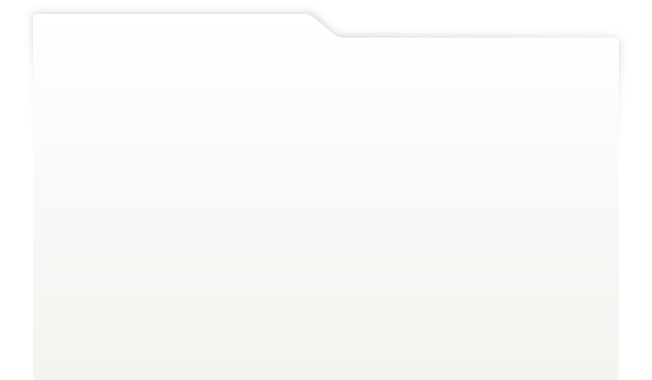
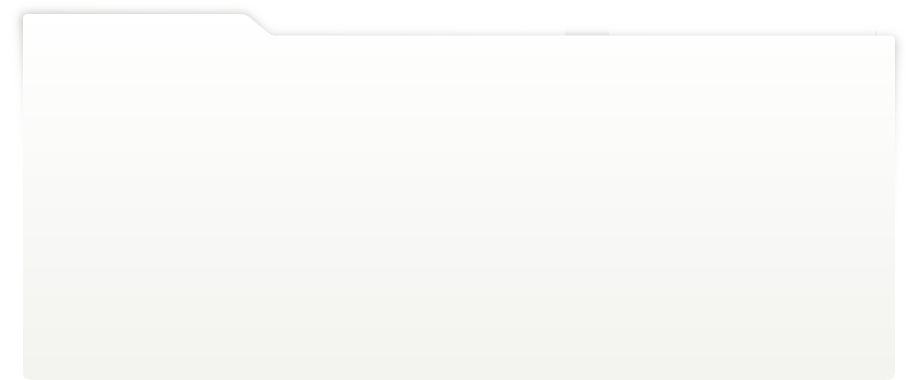
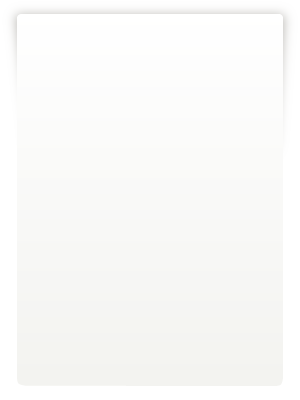
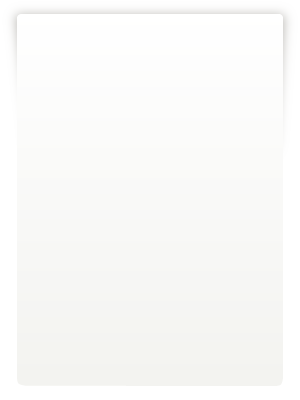
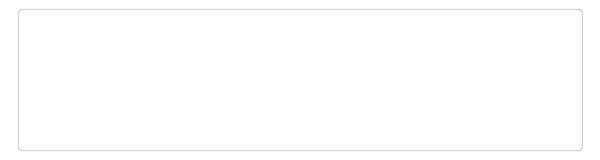
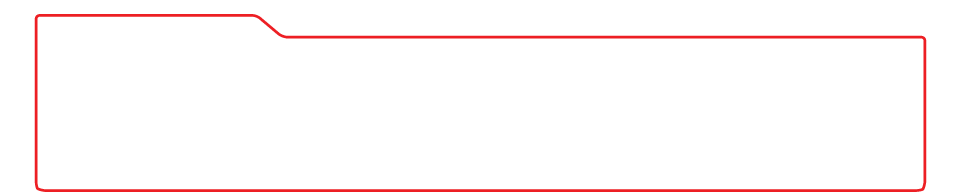
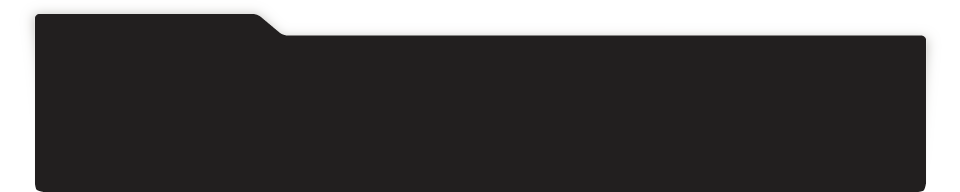
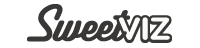
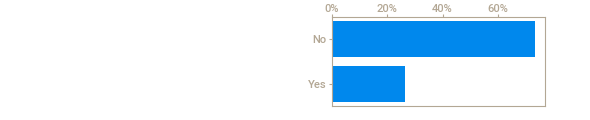
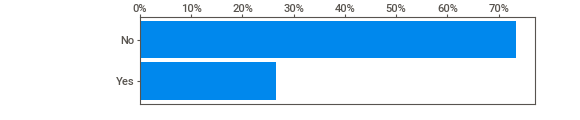
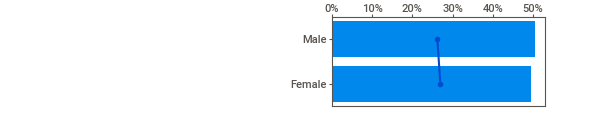
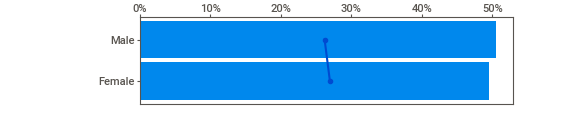
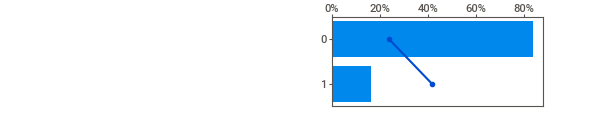
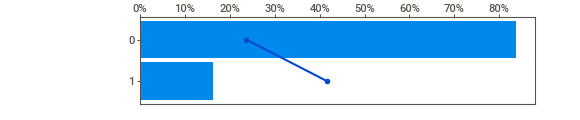
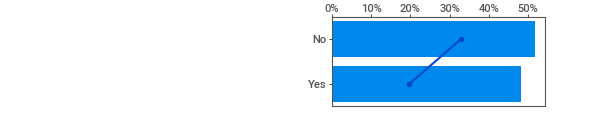
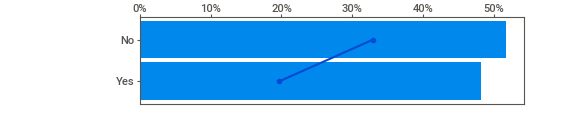
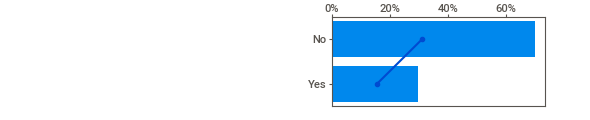
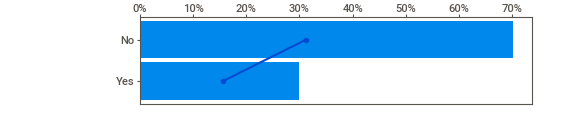
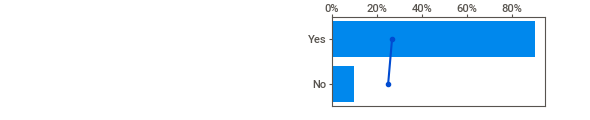
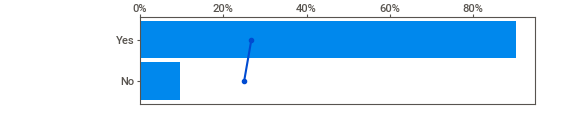
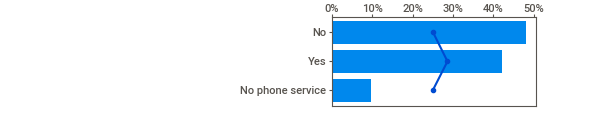
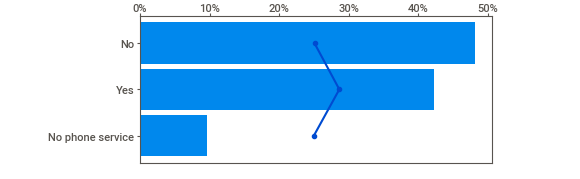
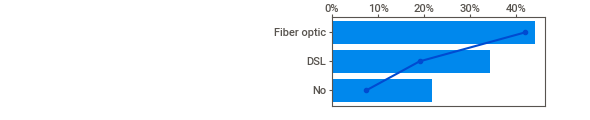
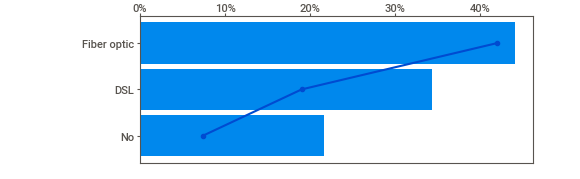
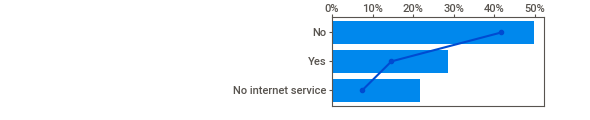
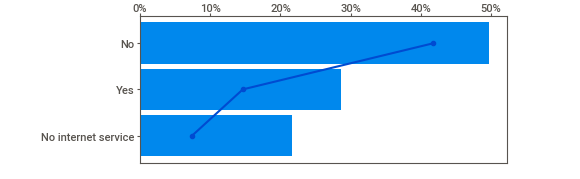
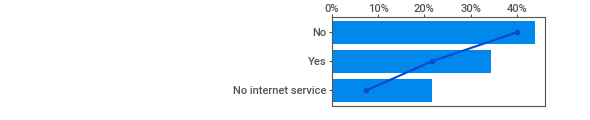
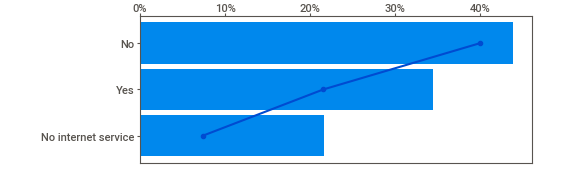
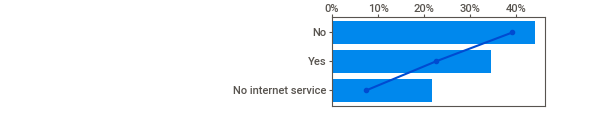
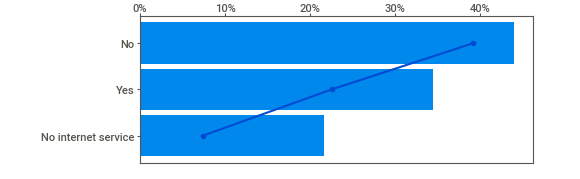
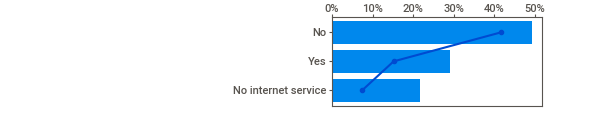
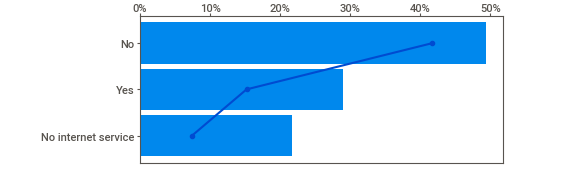
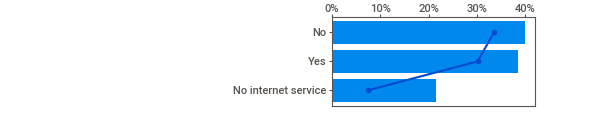
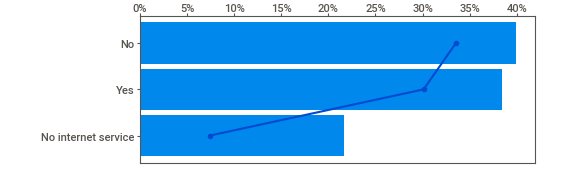
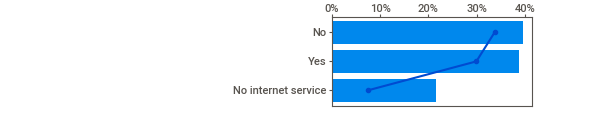
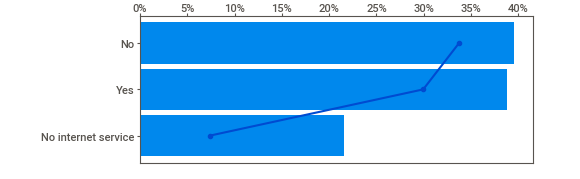
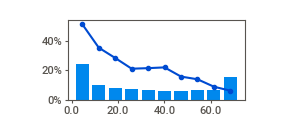
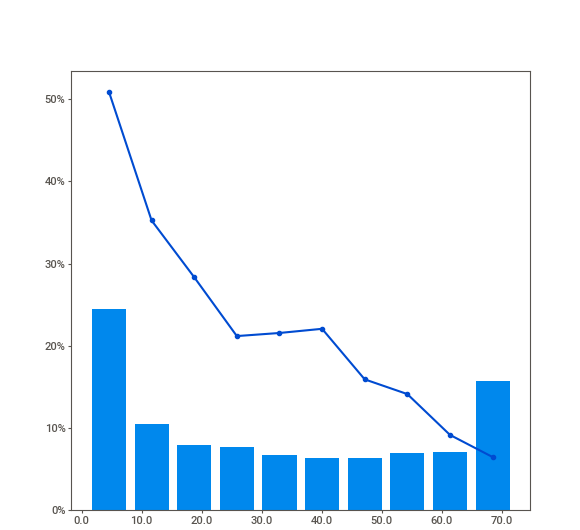
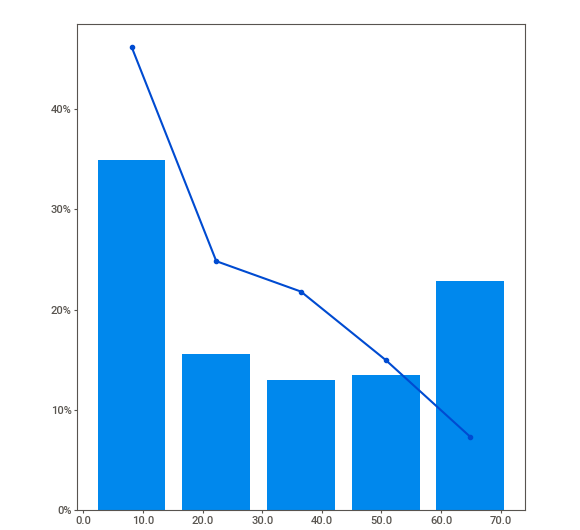
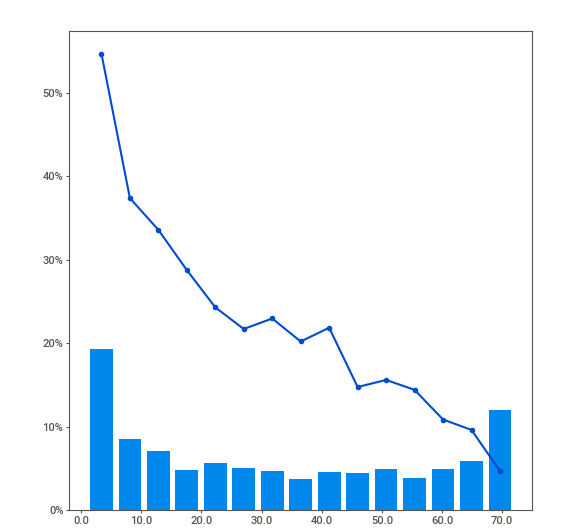
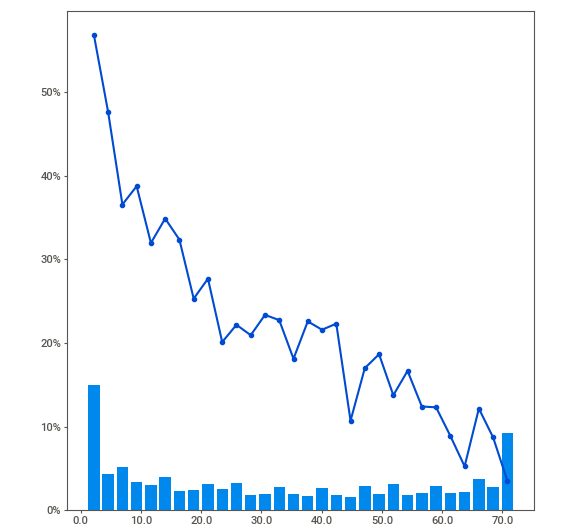
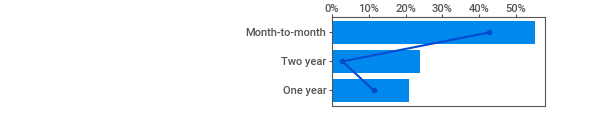
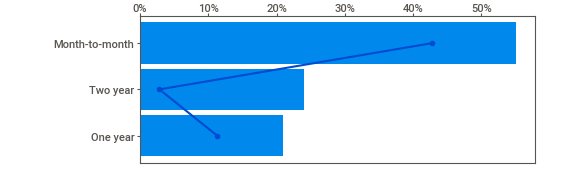
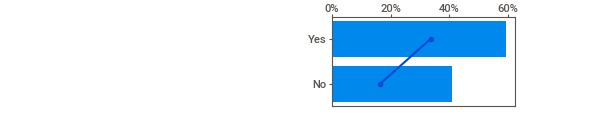
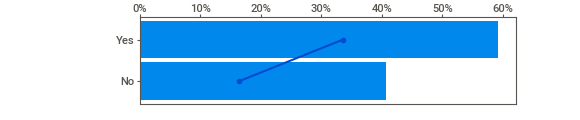
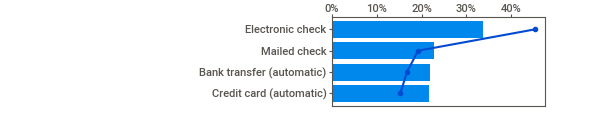
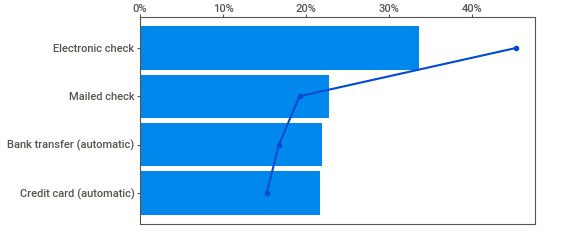
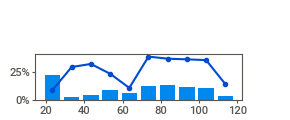
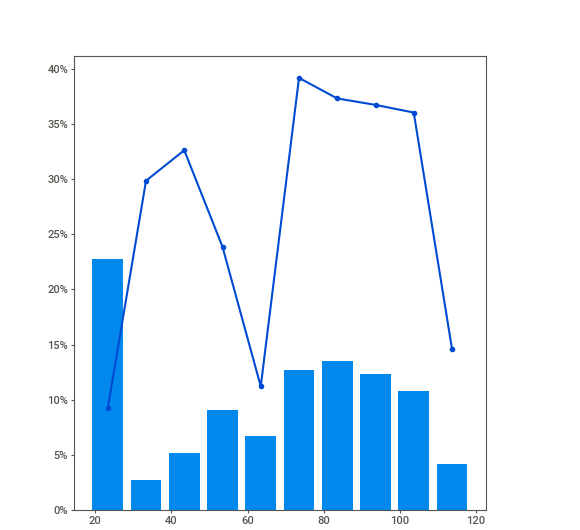
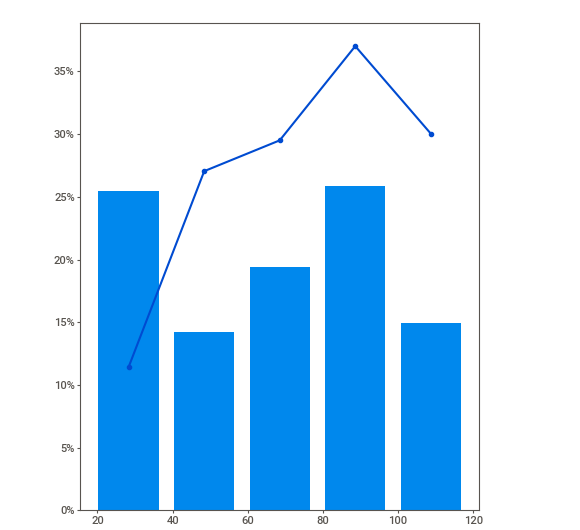
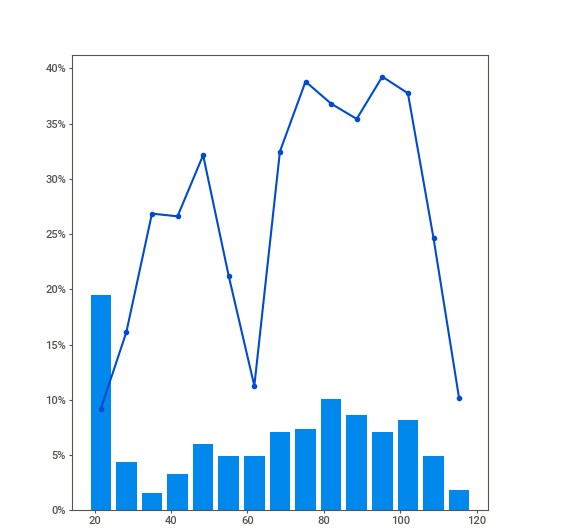
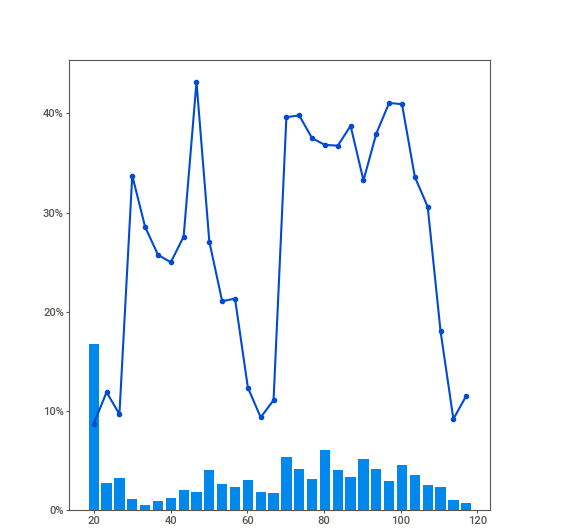
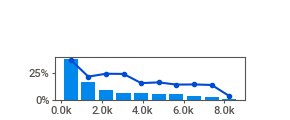
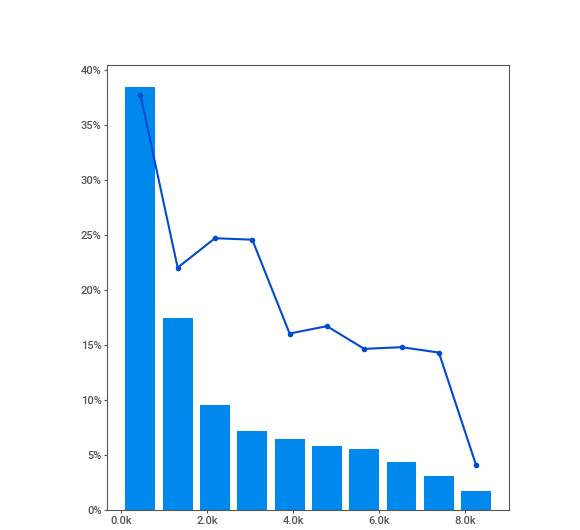
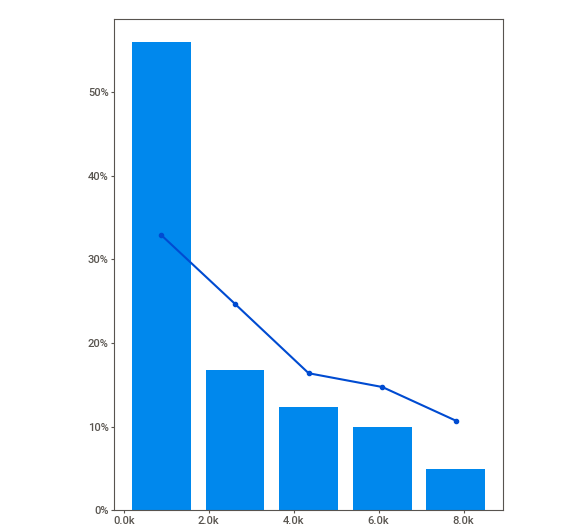
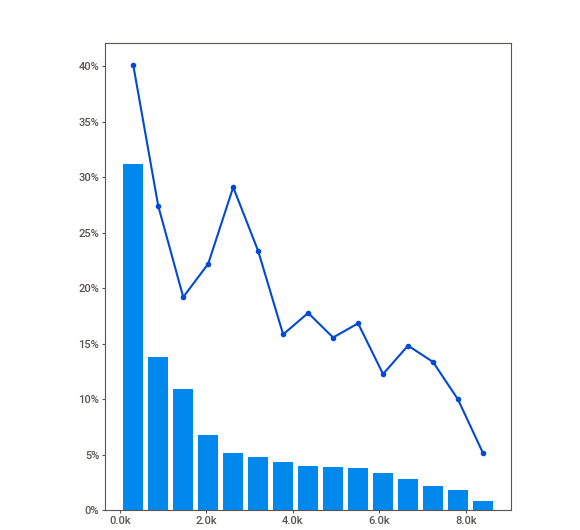
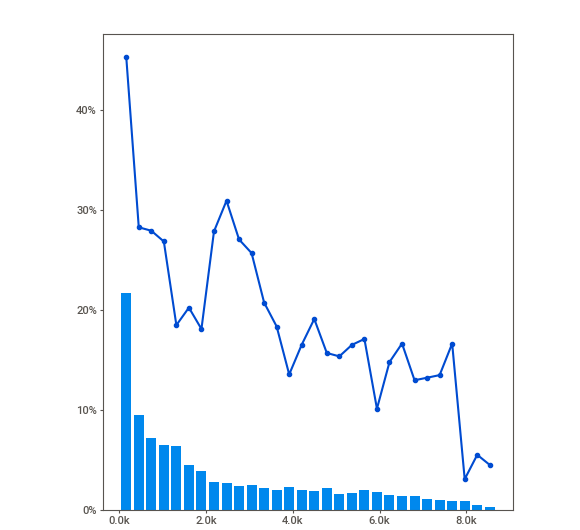
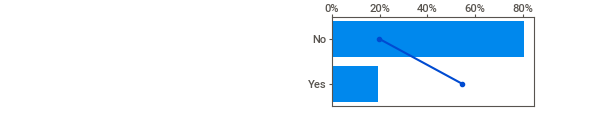
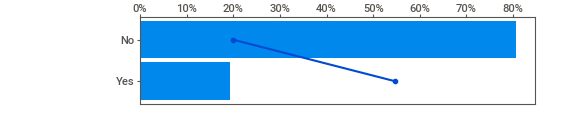
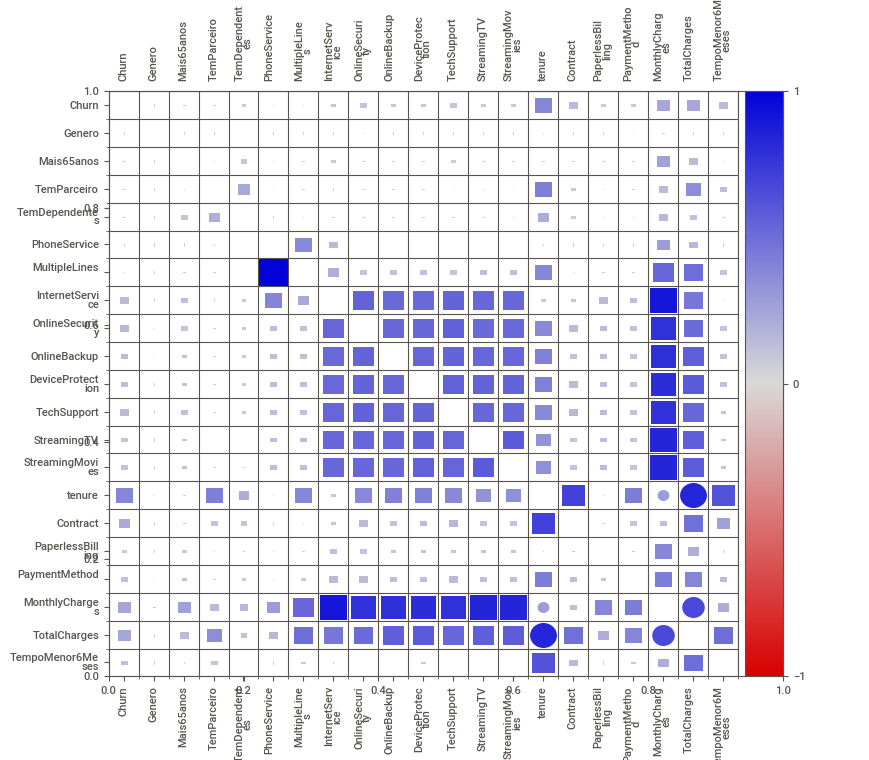
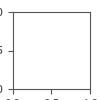

In [94]:
# sv_churn_report.show_html('churn_report.html')
sv_churn_report.show_notebook()